# PS_VS_SOLVER2 with clarabel solver for Coulumb friction model

In [1]:
import matplotlib.pyplot as plt
import scienceplots
import math
import numpy as np

def calculate_inclined_positions(angle_deg=15):
    """
    计算小方块在10度斜面上的位置
    
    参数:
    angle_deg: 斜面角度(度)
    """
    # 角度转换为弧度
    angle_rad = math.radians(angle_deg)
    
    # 当前参数
    ground_height = 0.5  # 地面几何中心z坐标
    ground_thickness = 1  # 地面厚度
    cube_size = 1         # 小方块尺寸
    
    # 计算斜面位置
    # 斜面绕x轴旋转10度，保持地面顶部与原点相切
    ground_pe = [0, 0, ground_height, 0, -angle_rad, 0]  # [x,y,z,rx,ry,rz]
    
    # 计算小方块位置
    # 小方块应该放在斜面上，底部四个小球与斜面接触
    cube_height = ground_height + (cube_size + ground_thickness) * 0.5 / math.cos(angle_rad)
    # cube_z_offset = sphere_radius + (cube_size/2 - 0.4)  # 考虑小球半径和几何偏移
    # cube_height = cube_z_offset + (cube_size/2) * math.sin(angle_rad)
    
    # 小方块的位置和姿态
    cube_pe = [0, 0, cube_height, 0, -angle_rad, 0]
    
    return ground_pe, cube_pe

  # import sys
  # sys.path.append("D:/code/sire/install/python/debug")
import sire
sim = sire.Simulator()
model = sim.model()
model.addSolvers()
simulator = sim.simulationLoop()
simulator.simDuration = 2
simulator.deltaT = 0.001
simulator.ctrlT = 10
simulator.setEventHandlerMap({0:9, 1:10, 2:11})
physicsEngine = sim.physicsEngine()
contactSolver = physicsEngine.addPsVsSolver2()
physicsEngine.collisionDetectionFlag = True
physicsEngine.contactSolverFlag = True
contactSolver.setDefaultProp("{k:1.4e8,d:10000,cr:0.2}")
# contactSolver.setDefaultProp("{k:2e7,d:10000,cr:0.2}")
# contactSolver.addMaterialPair("m1", "m1", "{k:2e8,d:10000,cr:0,cof:0.3,threshold_velocity:2e-6}")
contactSolver.addMaterialPair("m1", "m2", "{k:2e8,d:150000,cr:0.2,cof:0.2,threshold_velocity:1e-4}")
model.setGravity([0, 0, -9.81, 0, 0, 0])
model.ground().addMarker("joint_0_k")
model.ground().addMarker("ground_marker")
ground_pe, cube_pe = calculate_inclined_positions(15)
# cube_pe[2] = 2
ground_pm = sire.pe3132tfmatrix(ground_pe).tolist()
model.ground().addBoxGeometry(0, 100, 100, 1, [1,0,0,0,0,1,0,0,0,0,1,-0.5,0,0,0,1])
model.ground().addBoxGeometry(0, 5, 5, 1, ground_pm)

physicsEngine.addBoxGeometry(100, 100, 1, 0, False, [1,0,0,0,0,1,0,0,0,0,1,-0.5,0,0,0,1])
physicsEngine.addBoxGeometry(5, 5, 1, 0, False, ground_pm)
# sliderPrt = model.addPartByPe(ground_pe, "313", [10, 0, 0, 0, 0.1, 0.1, 0.1, 0, 0, 0])
# model.link(1).addMarker("slider_center")
boxPrt = model.addPartByPe(cube_pe, "313", [1, 0, 0, 0, 0.1, 0.1, 0.1, 0, 0, 0])
model.link(1).addMarker("box_center")
model.init()
boxPrt.addBoxGeometry(boxPrt.id, 1.0, 1.0, 1.0, prt_pm=[1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1])
boxPrt.cptGeometryInertial2Part(1)
boxPrt.vs = sire.vp2vs(cube_pe[:3], [0, -2 * math.cos(math.radians(15)), 2 * math.sin(math.radians(15))])

physicsEngine.addBoxGeometry(1, 1, 1, boxPrt.id, True)
physicsEngine.addSphereGeometry(0.1, boxPrt.id, True, [1,0,0,0.5,0,1,0,0.5,0,0,1,-0.4,0,0,0,1], material="m2")
physicsEngine.addSphereGeometry(0.1, boxPrt.id, True, [1,0,0,0.5,0,1,0,-0.5,0,0,1,-0.4,0,0,0,1], material="m2")
physicsEngine.addSphereGeometry(0.1, boxPrt.id, True, [1,0,0,-0.5,0,1,0,0.5,0,0,1,-0.4,0,0,0,1], material="m2")
physicsEngine.addSphereGeometry(0.1, boxPrt.id, True, [1,0,0,-0.5,0,1,0,-0.5,0,0,1,-0.4,0,0,0,1], material="m2")
# print(sire.toXmlString(sim))
sim.init()
for i in range(4):
  physicsEngine.collisionFilter().enableCollisionPair(1, i + 3)

physicsEngine.collisionFilter().saveMatConfig()
print(sire.toXmlString(sim))

count = 0
while(not simulator.isTimeout() and not simulator.isEventListEmpty()):
  sim_time = simulator.simTime()
  # if abs(sim_time - 0.37) < 1e-8 and count == 0:
  #   print(boxPrt.getAs())
  #   count += 1
  simulator.step(1, False)

simulator.recordsContactCptInfo()
displayInitJson = model.displayInitJson()
result = simulator.recordsToJson()

# pltResult = result
# timeIndices = pltResult['timeIndex']
# pp = pltResult["penetrationPairs"]  # contactInfo is renamed to penetrationPairs in the latest code
# partpq = pltResult["partPq"]
# partvs = pltResult["partVs"]
# partas = pltResult["partAs"]
# gf = pltResult["generalForces"]
# dts = pltResult["dts"]
# x = []
# y = []
# yv = []
# # print(result[i][2])

# lowerBound = sire.binarySearch(timeIndices, 0.16)
# upperBound = sire.binarySearch(timeIndices, 0.198)
# print(lowerBound, upperBound)
# # with open('hfield_data.txt', 'w') as f:          # 'w' 覆盖写，'a' 追加写
# # with open('box_data.txt', 'w') as f:          # 'w' 覆盖写，'a' 追加写
# for j in range(lowerBound, upperBound):
#     # print(j, f"{timeIndices[j]:.4f}", f"{dts[j]:.4f}", f"{partpq[j][1][2]:.6f}", f"{partvs[j][1][2]:.6f}", f"{partas[j][1][2]:.6f}", pp[j], gf[j], file=f)
#   print(j, f"{timeIndices[j]:.4f}", f"{dts[j]:.4f}", f"{partpq[j][1][2]:.6f}", f"{partvs[j][1][2]:.6f}", f"{partas[j][1][2]:.6f}", pp[j], gf[j])

print("Simulation finished, records loaded")
import meshcat
vis = meshcat.Visualizer()
resourcePath = "D:/code/sire/web_interface/public"
sire.robotInit(model.numLinks(), resourcePath, displayInitJson, vis)
sire.animateRobotByRecords(model.numLinks(), result, 1000, vis)
# cs.clear()
vis.jupyter_cell()

<Simulator>
    <Model __prop_name__="model" name="object" time="0">
        <Environment __prop_name__="environment" gravity="{0,0,-9.81,0,0,0}"/>
        <VariablePoolElement __prop_name__="variable_pool"/>
        <PartPoolElement __prop_name__="part_pool">
            <Part name="ground" active="true" pe="{0,0,0,-0,0,-0}" vel="{0,0,0,0,0,0}" acc="{0,0,0,0,0,0}" inertia="{1,0,0,0,1,1,1,0,0,0}">
                <MarkerPoolElement __prop_name__="marker_pool">
                    <Marker name="joint_0_k" active="true" pe="{0,0,0,-0,0,-0}"/>
                    <Marker name="ground_marker" active="true" pe="{0,0,0,-0,0,-0}"/>
                </MarkerPoolElement>
                <GeometryPoolElement __prop_name__="geometry_pool">
                    <BoxGeometry id="0" pm="{1,0,0,0,0,1,0,0,0,0,1,-0.5,0,0,0,1}" part_id="0" is_dynamic="true" side="{100,100,1}"/>
                    <BoxGeometry id="1" pm="{1,-0,0,0,0,0.965925826289068,0.258819045102521,0,-0,-0.258819045102521,0.96592582628

0.0 0.001


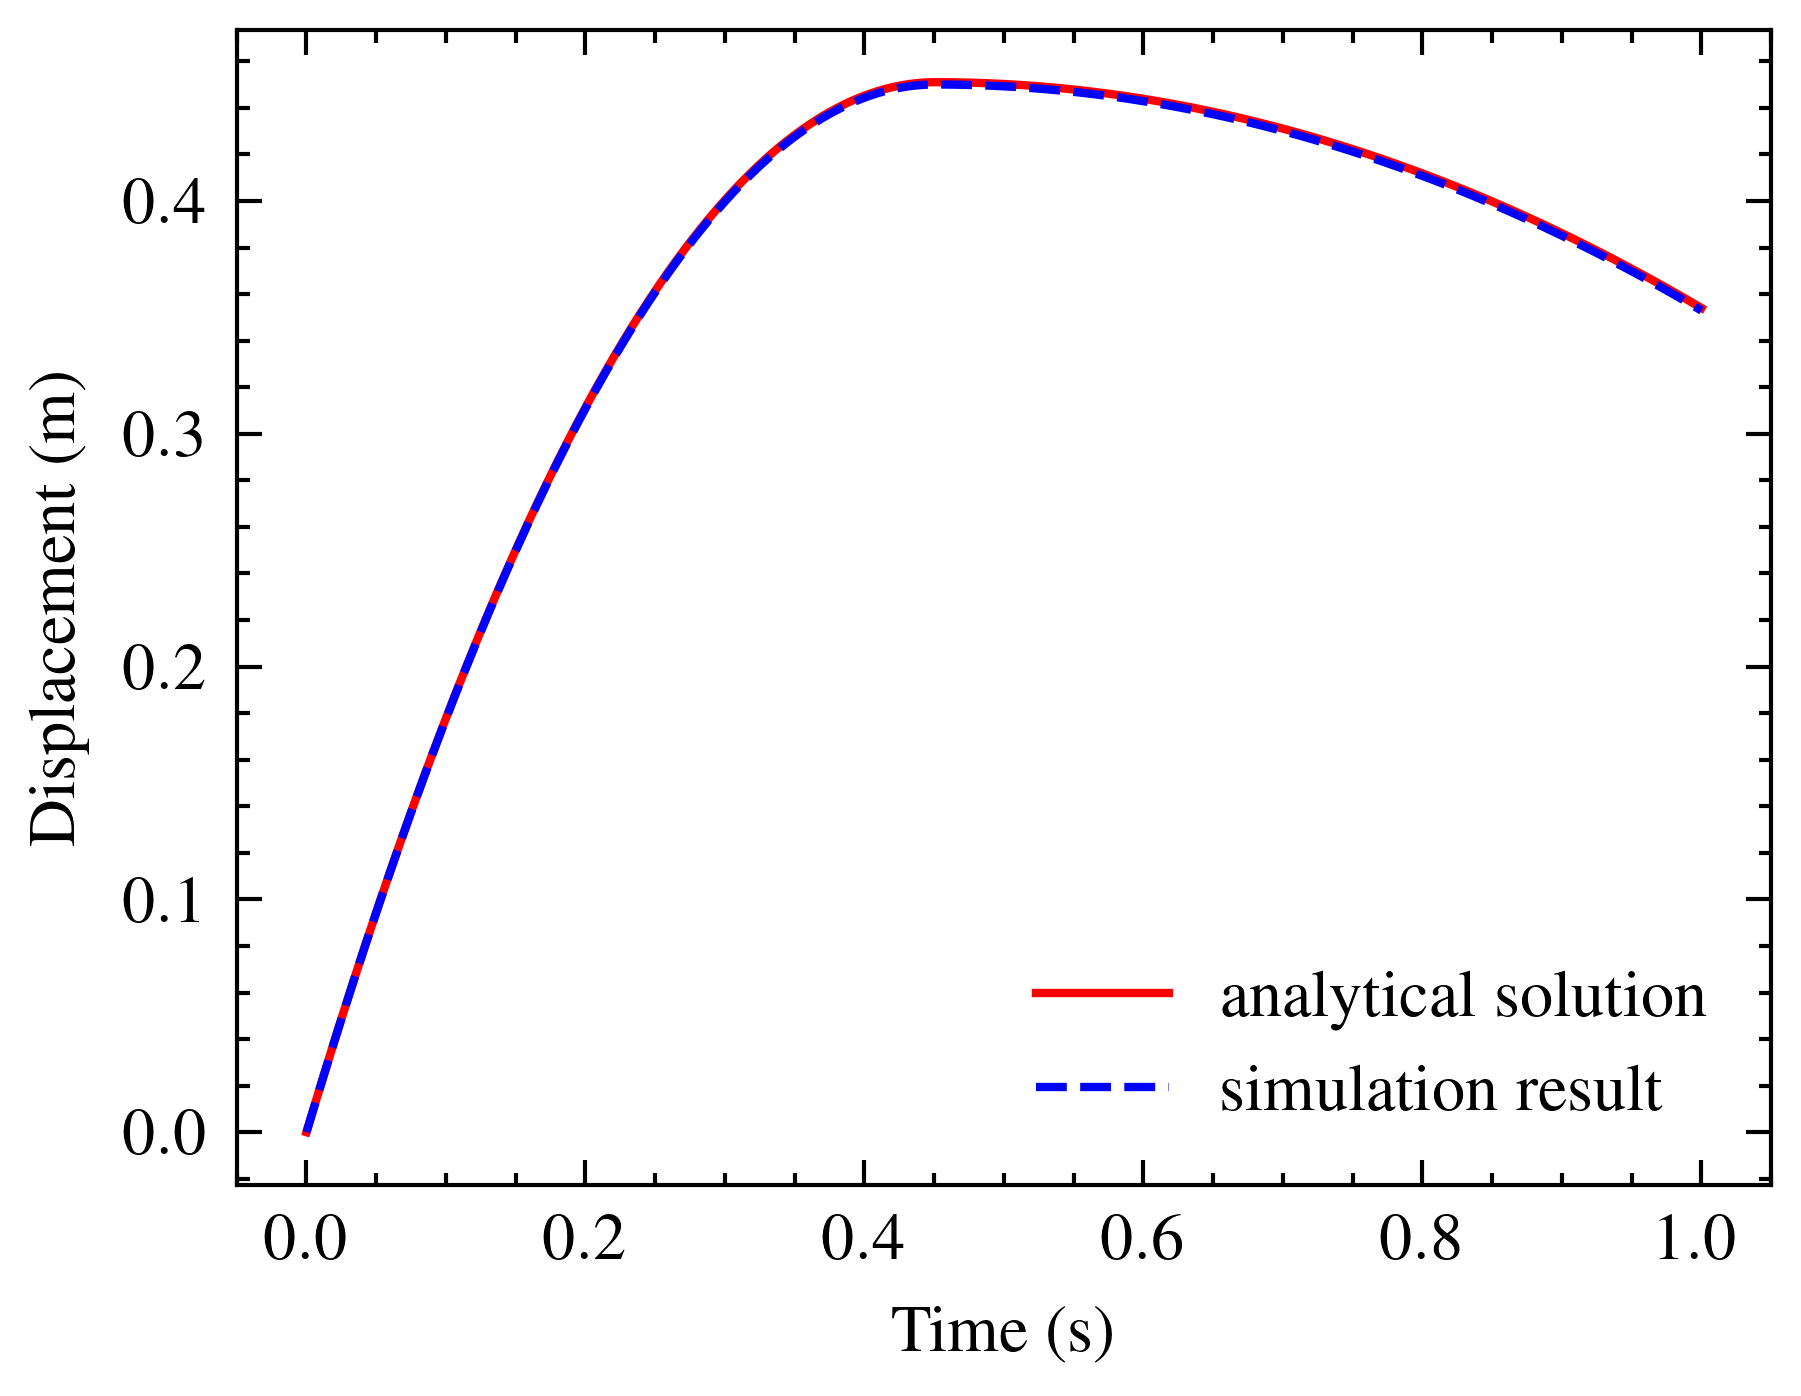

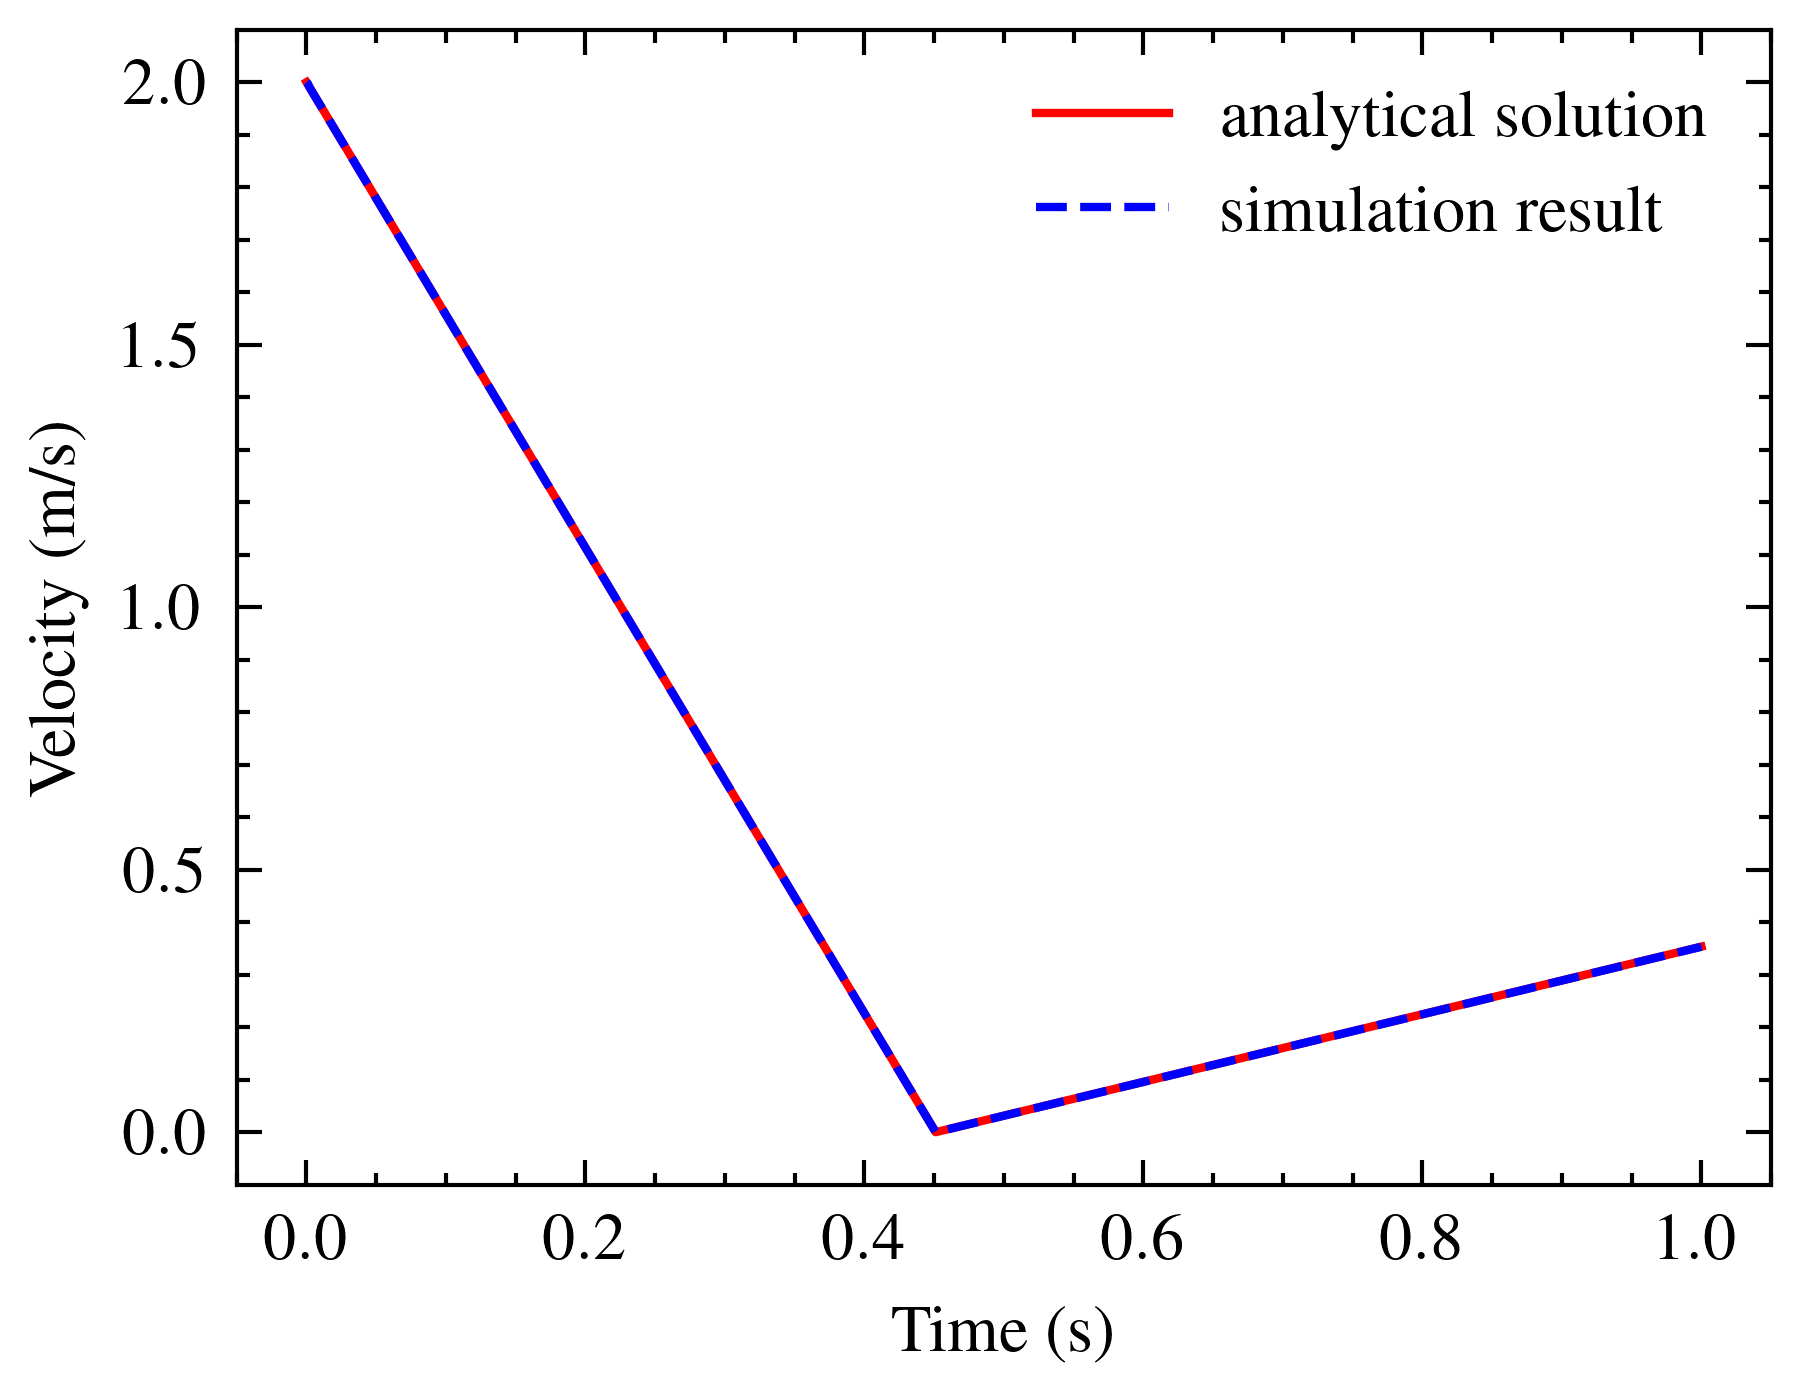

In [2]:
import numpy as np
plot_time = 1
timeIndices = result['timeIndex']
contactInfo = result["contactInfo"]
partpq = result["partPq"]
partvs = result["partVs"]
partas = result["partAs"]
dts = result["dts"]
x = []
y = []
yv = []

lowerBound = sire.binarySearch(timeIndices, 0)
upperBound = sire.binarySearch(timeIndices, 0 + plot_time)
print(timeIndices[lowerBound], timeIndices[lowerBound + 1])
for i in range(lowerBound, upperBound + 1):
  # print(i, timeIndices[i], dts[i], partpq[i][1], partvs[i][1], partas[i][1], contactInfo[i])
  x.append(timeIndices[i])
  pm = sire.pq2tfmatrix(partpq[i][1])
  yOffset = pm[1, 3]
  zOffset = pm[2, 3] - cube_pe[2]
  y.append(math.sqrt(yOffset ** 2 + zOffset ** 2))  # displacement along incline
  yv.append(math.sqrt(partvs[i][1][2] ** 2 + partvs[i][1][1]**2))  # speed along incline

# mu=0.2 < tan(15°)=0.268, box slides back downhill after stopping
a1 = 9.81 * math.sin(math.radians(15)) + 0.2 * 9.81 * math.cos(math.radians(15))  # uphill decel
a2 = 9.81 * math.sin(math.radians(15)) - 0.2 * 9.81 * math.cos(math.radians(15))  # downhill accel
t_stop = 2 / a1
x_stop = 2 * t_stop - 0.5 * a1 * t_stop ** 2

x2 = np.linspace(0, plot_time, 10000)
y2 = np.piecewise(x2, 
                 [x2 <= t_stop, x2 > t_stop], 
                 [lambda x: 2 * x - 0.5 * a1 * x ** 2,
                  lambda x: x_stop - 0.5 * a2 * (x - t_stop) ** 2])
with plt.style.context(['science','ieee']):
  plt.plot(x2, y2, color='red', linestyle="-", label="analytical solution")
  plt.plot(x, y, color='blue', linestyle="--", label="simulation result")
  plt.legend()
  plt.xlabel("Time (s)")
  plt.ylabel("Displacement (m)")
  # plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data2.pdf", format="pdf")
  plt.show()

  x1 = np.linspace(0, plot_time, 10000)
  y1 = np.piecewise(x1, 
                   [x1 < t_stop, x1 >= t_stop], 
                   [lambda x: 2 - a1 * x,
                    lambda x: a2 * (x - t_stop)])
  plt.plot(x1, y1, color='red', linestyle="-", label="analytical solution")
  plt.plot(x, yv, color='blue', linestyle="--", label="simulation result")
  plt.xlabel("Time (s)")
  plt.ylabel("Velocity (m/s)")
  plt.legend()
  plt.show()


  Sire Accuracy Metrics — Box Sliding on 15° Incline (mu=0.2)
  (mu < tan(15°)=0.268, box slides back downhill)

                                  — Full Trajectory (0 — 1.0s) —
                                    Displacement        Velocity
  --------------------------------------------------------------
  RMSE:                                 0.000863        0.000137
  MAE:                                  0.000796        0.000093
  Max absolute error:                   0.001084        0.001918
  R² score:                             0.999938        1.000000

                              — Turning Point (t_stop=0.4510s) —
  Analytical x_stop:                    0.451044 m
  Sire displacement at t_stop:          0.450046 m
  Absolute difference:                  0.000998 m
[0.00e+00 1.00e-03 2.00e-03 3.00e-03 4.00e-03 5.00e-03 6.00e-03 7.00e-03
 8.00e-03 9.00e-03 1.00e-02 1.10e-02 1.20e-02 1.30e-02 1.40e-02 1.50e-02
 1.60e-02 1.70e-02 1.80e-02 1.90e-02 2.00e-02 2.10e-02 2.20e-02 2.

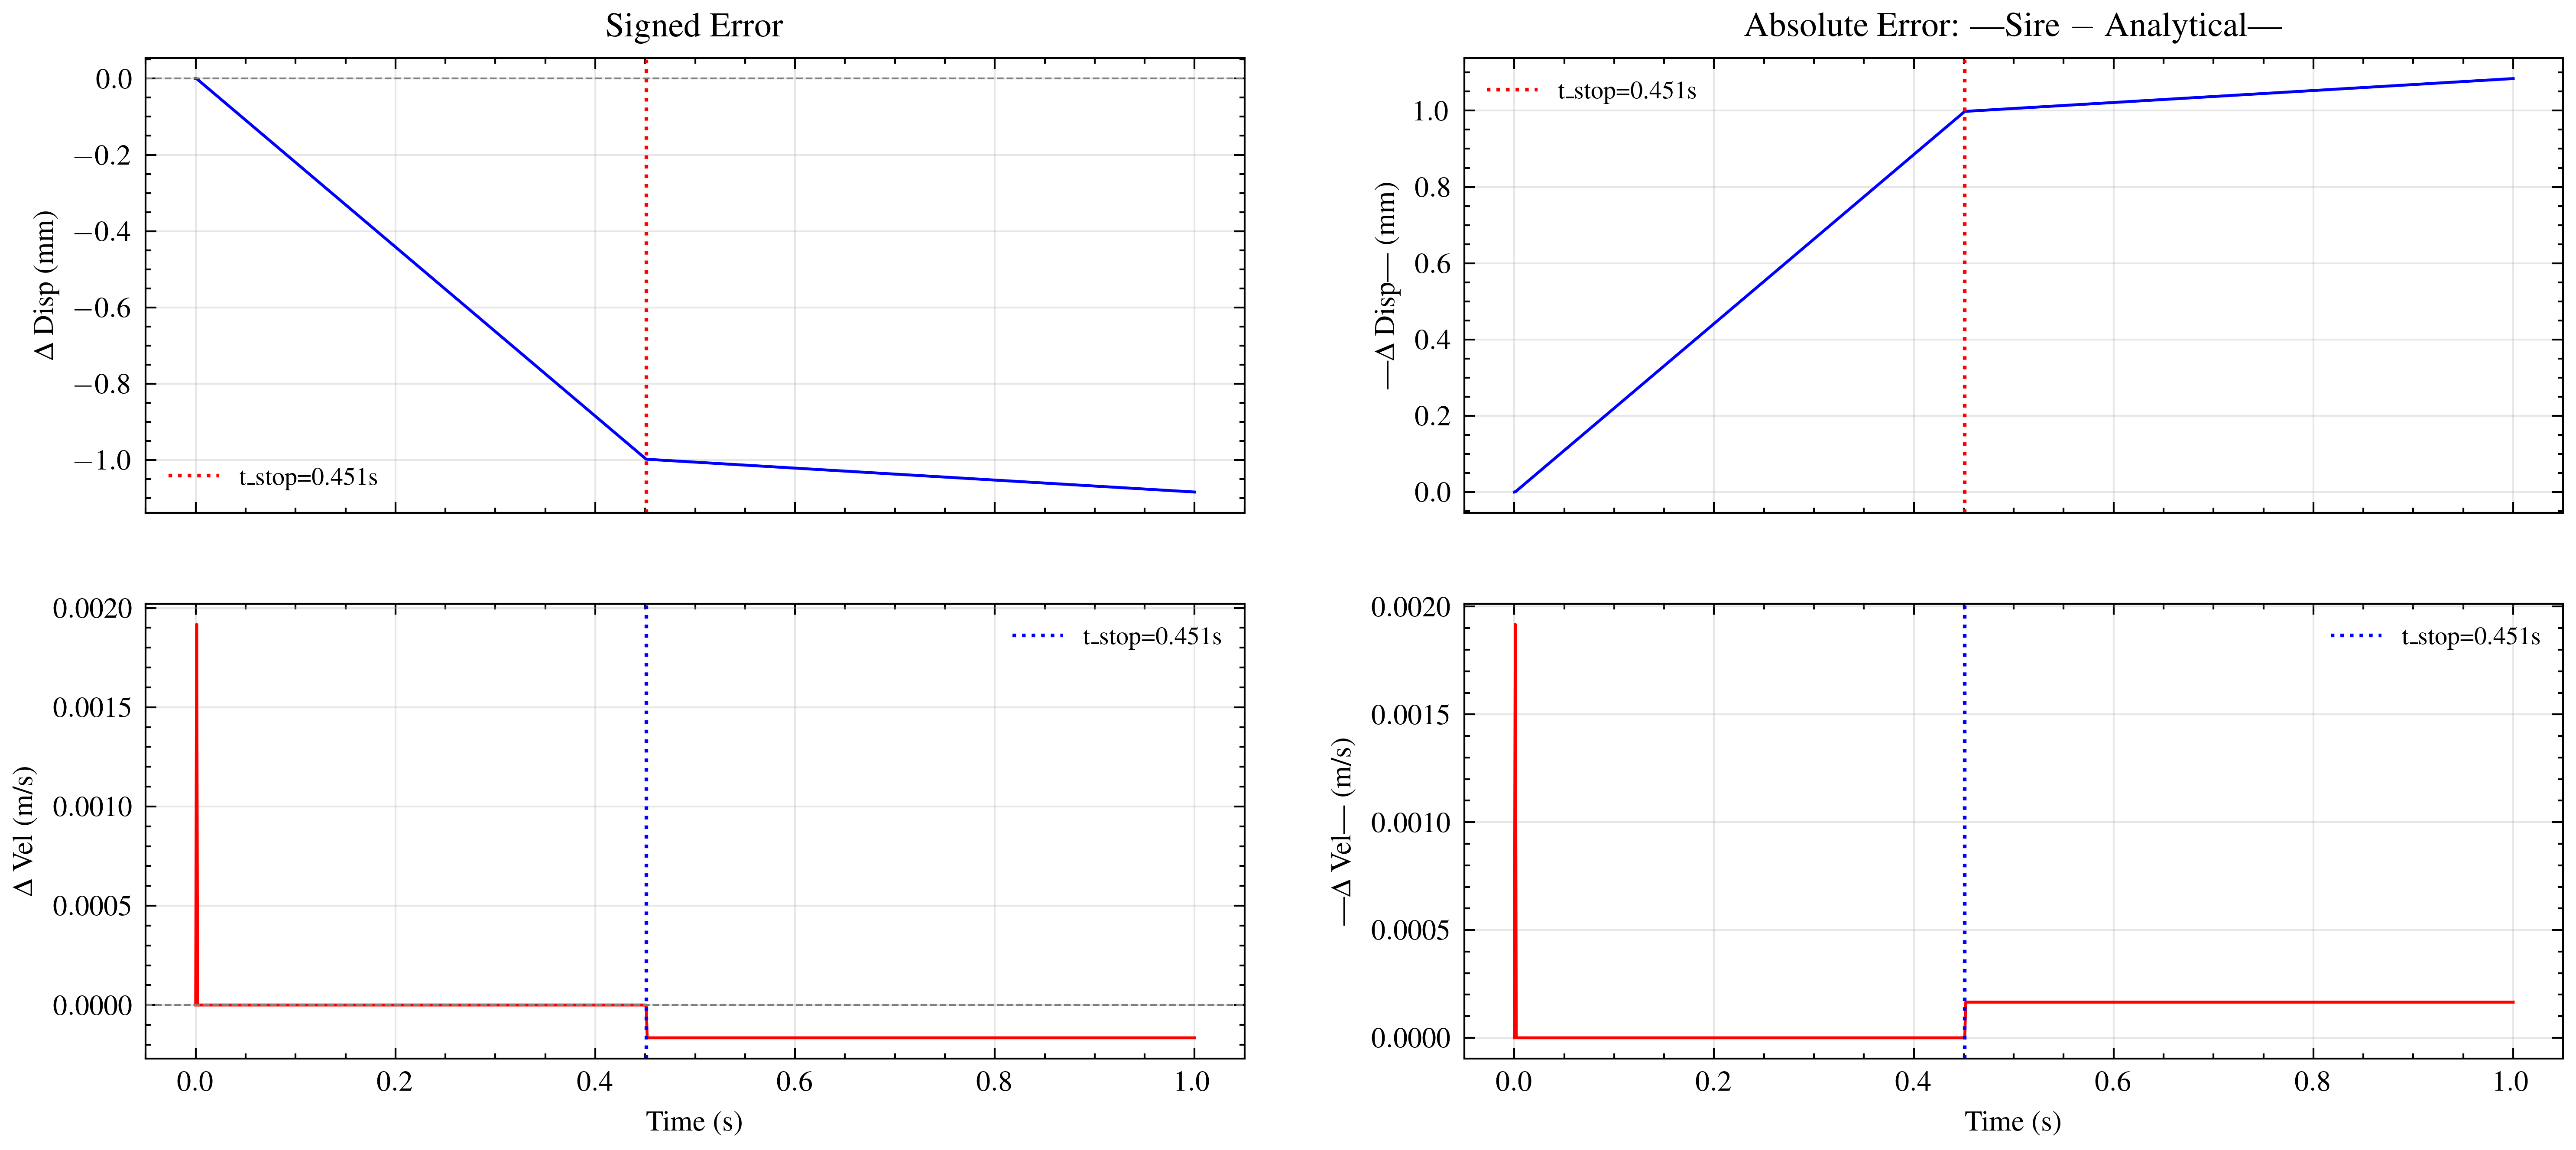

In [3]:
import numpy as np
import math
import matplotlib.pyplot as plt

# ======================== Parameters & Analytical ========================
angle_deg = 15
angle_rad = math.radians(angle_deg)
g = 9.81
mu = 0.2
v0 = 2.0
# mu < tan(15°), so after stopping uphill, box slides back downhill
a1 = g * math.sin(angle_rad) + mu * g * math.cos(angle_rad)  # uphill deceleration
a2 = g * math.sin(angle_rad) - mu * g * math.cos(angle_rad)  # downhill acceleration
t_stop = v0 / a1
x_stop = v0 * t_stop - 0.5 * a1 * t_stop**2

# ======================== Analytical curves (fine grid) ========================
t_ana = np.linspace(0, plot_time, 10000)
disp_ana = np.piecewise(t_ana,
                        [t_ana <= t_stop, t_ana > t_stop],
                        [lambda t: v0*t - 0.5*a1*t**2,
                         lambda t: x_stop - 0.5*a2*(t - t_stop)**2])
vel_ana = np.piecewise(t_ana,
                       [t_ana < t_stop, t_ana >= t_stop],
                       [lambda t: v0 - a1*t,
                        lambda t: a2*(t - t_stop)])

# Interpolate analytical onto sire time points
x_arr = np.array(x)
y_arr = np.array(y)
yv_arr = np.array(yv)

disp_ana_at_sire = np.interp(x_arr, t_ana, disp_ana)
vel_ana_at_sire = np.interp(x_arr, t_ana, vel_ana)

# ======================== Full-Trajectory Errors ========================
disp_error = y_arr - disp_ana_at_sire
vel_error = yv_arr - vel_ana_at_sire

disp_rmse_full = np.sqrt(np.mean(disp_error**2))
vel_rmse_full = np.sqrt(np.mean(vel_error**2))
disp_mae_full = np.mean(np.abs(disp_error))
vel_mae_full = np.mean(np.abs(vel_error))
disp_max_err = np.max(np.abs(disp_error))
vel_max_err = np.max(np.abs(vel_error))

ss_res_d = np.sum(disp_error**2)
ss_tot_d = np.sum((y_arr - np.mean(y_arr))**2)
r2_disp = 1 - ss_res_d / ss_tot_d if ss_tot_d > 1e-15 else 1.0

ss_res_v = np.sum(vel_error**2)
ss_tot_v = np.sum((yv_arr - np.mean(yv_arr))**2)
r2_vel = 1 - ss_res_v / ss_tot_v if ss_tot_v > 1e-15 else 1.0

# ======================== Turning-Point Error ========================
# Find the closest time point to t_stop
idx_stop = np.argmin(np.abs(x_arr - t_stop))
disp_at_stop = y_arr[idx_stop]
disp_stop_err = abs(disp_at_stop - x_stop)

# ======================== Print Results ========================
print(f"\n{'='*62}")
print(f"  Sire Accuracy Metrics — Box Sliding on {angle_deg}° Incline (mu={mu})")
print(f"{'='*62}")
print(f"  (mu < tan({angle_deg}°)={math.tan(angle_rad):.3f}, box slides back downhill)")

traj_label = f"— Full Trajectory (0 — {plot_time:.1f}s) —"
print(f"\n  {traj_label:>62}")
print(f"  {'':>30} {'Displacement':>15} {'Velocity':>15}")
print(f"  {'-'*62}")
print(f"  {'RMSE:':<30} {disp_rmse_full:>15.6f} {vel_rmse_full:>15.6f}")
print(f"  {'MAE:':<30} {disp_mae_full:>15.6f} {vel_mae_full:>15.6f}")
print(f"  {'Max absolute error:':<30} {disp_max_err:>15.6f} {vel_max_err:>15.6f}")
print(f"  {'R² score:':<30} {r2_disp:>15.6f} {r2_vel:>15.6f}")

turn_label = f"— Turning Point (t_stop={t_stop:.4f}s) —"
print(f"\n  {turn_label:>62}")
print(f"  {'Analytical x_stop:':<30} {x_stop:>15.6f} m")
print(f"  {'Sire displacement at t_stop:':<30} {disp_at_stop:>15.6f} m")
print(f"  {'Absolute difference:':<30} {disp_stop_err:>15.6f} m")
print(f"{'='*62}")

# ======================== Plots ========================
with plt.style.context(['science', 'ieee']):
    # --- Error-over-time (2x2: signed + absolute) ---
    fig, axes = plt.subplots(2, 2, figsize=(12, 5), sharex=True)

    axes[0, 0].plot(x_arr, disp_error * 1000, 'b-', linewidth=0.8)
    axes[0, 0].axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
    axes[0, 0].axvline(x=t_stop, color='r', linestyle=':', linewidth=1.0, label=f't_stop={t_stop:.3f}s')
    axes[0, 0].set_ylabel("$\\Delta$ Disp (mm)")
    axes[0, 0].set_title("Signed Error")
    axes[0, 0].legend(fontsize=7)
    axes[0, 0].grid(True, alpha=0.3)
    np.set_printoptions(threshold=np.inf)
    print(x_arr)
    print(disp_error)
    print(vel_error)

    axes[0, 1].plot(x_arr, np.abs(disp_error) * 1000, 'b-', linewidth=0.8)
    axes[0, 1].axvline(x=t_stop, color='r', linestyle=':', linewidth=1.0, label=f't_stop={t_stop:.3f}s')
    axes[0, 1].set_ylabel("|$\\Delta$ Disp| (mm)")
    axes[0, 1].set_title("Absolute Error: |Sire $-$ Analytical|")
    axes[0, 1].legend(fontsize=7)
    axes[0, 1].grid(True, alpha=0.3)

    axes[1, 0].plot(x_arr, vel_error, 'r-', linewidth=0.8)
    axes[1, 0].axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
    axes[1, 0].axvline(x=t_stop, color='b', linestyle=':', linewidth=1.0, label=f't_stop={t_stop:.3f}s')
    axes[1, 0].set_xlabel("Time (s)")
    axes[1, 0].set_ylabel("$\\Delta$ Vel (m/s)")
    axes[1, 0].legend(fontsize=7)
    axes[1, 0].grid(True, alpha=0.3)

    axes[1, 1].plot(x_arr, np.abs(vel_error), 'r-', linewidth=0.8)
    axes[1, 1].axvline(x=t_stop, color='b', linestyle=':', linewidth=1.0, label=f't_stop={t_stop:.3f}s')
    axes[1, 1].set_xlabel("Time (s)")
    axes[1, 1].set_ylabel("|$\\Delta$ Vel| (m/s)")
    axes[1, 1].legend(fontsize=7)
    axes[1, 1].grid(True, alpha=0.3)

    plt.show()

# Analytical Tangential Solver

In [4]:
import matplotlib.pyplot as plt
import scienceplots
import math
import numpy as np

def calculate_inclined_positions(angle_deg=10):
    """
    计算小方块在10度斜面上的位置
    
    参数:
    angle_deg: 斜面角度(度)
    """
    # 角度转换为弧度
    angle_rad = math.radians(angle_deg)
    
    # 当前参数
    ground_height = 0.5  # 地面几何中心z坐标
    ground_thickness = 1  # 地面厚度
    cube_size = 1         # 小方块尺寸
    
    # 计算斜面位置
    # 斜面绕x轴旋转10度，保持地面顶部与原点相切
    ground_pe = [0, 0, ground_height, 0, -angle_rad, 0]  # [x,y,z,rx,ry,rz]
    
    # 计算小方块位置
    # 小方块应该放在斜面上，底部四个小球与斜面接触
    cube_height = ground_height + (cube_size + ground_thickness) * 0.5 / math.cos(angle_rad)
    # cube_z_offset = sphere_radius + (cube_size/2 - 0.4)  # 考虑小球半径和几何偏移
    # cube_height = cube_z_offset + (cube_size/2) * math.sin(angle_rad)
    
    # 小方块的位置和姿态
    cube_pe = [0, 0, cube_height, 0, -angle_rad, 0]
    
    return ground_pe, cube_pe

  # import sys
  # sys.path.append("D:/code/sire/install/python/debug")
import sire
sim = sire.Simulator()
model = sim.model()
model.addSolvers()
simulator = sim.simulationLoop()
simulator.simDuration = 2
simulator.deltaT = 0.001
simulator.ctrlT = 10
simulator.setEventHandlerMap({0:9, 1:10, 2:11})
physicsEngine = sim.physicsEngine()
contactSolver = physicsEngine.addAnalyticalTangentForceSolver()
physicsEngine.collisionDetectionFlag = True
physicsEngine.contactSolverFlag = True
contactSolver.setDefaultProp("{k:1.4e8,d:10000,cr:0.2}")
# contactSolver.setDefaultProp("{k:2e7,d:10000,cr:0.2}")
# contactSolver.addMaterialPair("m1", "m1", "{k:2e8,d:10000,cr:0,cof:0.3,threshold_velocity:2e-6}")
contactSolver.addMaterialPair("m1", "m2", "{k:2e8,d:150000,cr:0.2,cof:0.2,threshold_velocity:1e-4}")
model.setGravity([0, 0, -9.81, 0, 0, 0])
model.ground().addMarker("joint_0_k")
model.ground().addMarker("ground_marker")
ground_pe, cube_pe = calculate_inclined_positions(15)
# cube_pe[2] = 2
ground_pm = sire.pe3132tfmatrix(ground_pe).tolist()
model.ground().addBoxGeometry(0, 100, 100, 1, [1,0,0,0,0,1,0,0,0,0,1,-0.5,0,0,0,1])
model.ground().addBoxGeometry(0, 5, 5, 1, ground_pm)

physicsEngine.addBoxGeometry(100, 100, 1, 0, False, [1,0,0,0,0,1,0,0,0,0,1,-0.5,0,0,0,1])
physicsEngine.addBoxGeometry(5, 5, 1, 0, False, ground_pm)
# sliderPrt = model.addPartByPe(ground_pe, "313", [10, 0, 0, 0, 0.1, 0.1, 0.1, 0, 0, 0])
# model.link(1).addMarker("slider_center")
boxPrt = model.addPartByPe(cube_pe, "313", [1, 0, 0, 0, 0.1, 0.1, 0.1, 0, 0, 0])
model.link(1).addMarker("box_center")
model.init()
boxPrt.addBoxGeometry(boxPrt.id, 1.0, 1.0, 1.0, prt_pm=[1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1])
boxPrt.cptGeometryInertial2Part(1)
boxPrt.vs = sire.vp2vs(cube_pe[:3], [0, -2 * math.cos(math.radians(15)), 2 * math.sin(math.radians(15))])

physicsEngine.addBoxGeometry(1, 1, 1, boxPrt.id, True)
physicsEngine.addSphereGeometry(0.1, boxPrt.id, True, [1,0,0,0.5,0,1,0,0.5,0,0,1,-0.4,0,0,0,1], material="m2")
physicsEngine.addSphereGeometry(0.1, boxPrt.id, True, [1,0,0,0.5,0,1,0,-0.5,0,0,1,-0.4,0,0,0,1], material="m2")
physicsEngine.addSphereGeometry(0.1, boxPrt.id, True, [1,0,0,-0.5,0,1,0,0.5,0,0,1,-0.4,0,0,0,1], material="m2")
physicsEngine.addSphereGeometry(0.1, boxPrt.id, True, [1,0,0,-0.5,0,1,0,-0.5,0,0,1,-0.4,0,0,0,1], material="m2")
# print(sire.toXmlString(sim))
sim.init()
for i in range(4):
  physicsEngine.collisionFilter().enableCollisionPair(1, i + 3)

physicsEngine.collisionFilter().saveMatConfig()
print(sire.toXmlString(sim))

count = 0
while(not simulator.isTimeout() and not simulator.isEventListEmpty()):
  sim_time = simulator.simTime()
  # if abs(sim_time - 0.37) < 1e-8 and count == 0:
  #   print(boxPrt.getAs())
  #   count += 1
  simulator.step(1, False)

simulator.recordsContactCptInfo()
displayInitJson = model.displayInitJson()
result = simulator.recordsToJson()

# pltResult = result
# timeIndices = pltResult['timeIndex']
# pp = pltResult["penetrationPairs"]  # contactInfo is renamed to penetrationPairs in the latest code
# partpq = pltResult["partPq"]
# partvs = pltResult["partVs"]
# partas = pltResult["partAs"]
# gf = pltResult["generalForces"]
# dts = pltResult["dts"]
# x = []
# y = []
# yv = []
# # print(result[i][2])

# lowerBound = sire.binarySearch(timeIndices, 0.16)
# upperBound = sire.binarySearch(timeIndices, 0.198)
# print(lowerBound, upperBound)
# # with open('hfield_data.txt', 'w') as f:          # 'w' 覆盖写，'a' 追加写
# # with open('box_data.txt', 'w') as f:          # 'w' 覆盖写，'a' 追加写
# for j in range(lowerBound, upperBound):
#     # print(j, f"{timeIndices[j]:.4f}", f"{dts[j]:.4f}", f"{partpq[j][1][2]:.6f}", f"{partvs[j][1][2]:.6f}", f"{partas[j][1][2]:.6f}", pp[j], gf[j], file=f)
#   print(j, f"{timeIndices[j]:.4f}", f"{dts[j]:.4f}", f"{partpq[j][1][2]:.6f}", f"{partvs[j][1][2]:.6f}", f"{partas[j][1][2]:.6f}", pp[j], gf[j])

print("Simulation finished, records loaded")
import meshcat
vis = meshcat.Visualizer()
resourcePath = "D:/code/sire/web_interface/public"
sire.robotInit(model.numLinks(), resourcePath, displayInitJson, vis)
sire.animateRobotByRecords(model.numLinks(), result, 1000, vis)
# cs.clear()
vis.jupyter_cell()

<Simulator>
    <Model __prop_name__="model" name="object" time="0">
        <Environment __prop_name__="environment" gravity="{0,0,-9.81,0,0,0}"/>
        <VariablePoolElement __prop_name__="variable_pool"/>
        <PartPoolElement __prop_name__="part_pool">
            <Part name="ground" active="true" pe="{0,0,0,-0,0,-0}" vel="{0,0,0,0,0,0}" acc="{0,0,0,0,0,0}" inertia="{1,0,0,0,1,1,1,0,0,0}">
                <MarkerPoolElement __prop_name__="marker_pool">
                    <Marker name="joint_0_k" active="true" pe="{0,0,0,-0,0,-0}"/>
                    <Marker name="ground_marker" active="true" pe="{0,0,0,-0,0,-0}"/>
                </MarkerPoolElement>
                <GeometryPoolElement __prop_name__="geometry_pool">
                    <BoxGeometry id="0" pm="{1,0,0,0,0,1,0,0,0,0,1,-0.5,0,0,0,1}" part_id="0" is_dynamic="true" side="{100,100,1}"/>
                    <BoxGeometry id="1" pm="{1,-0,0,0,0,0.965925826289068,0.258819045102521,0,-0,-0.258819045102521,0.96592582628

0.0 0.001


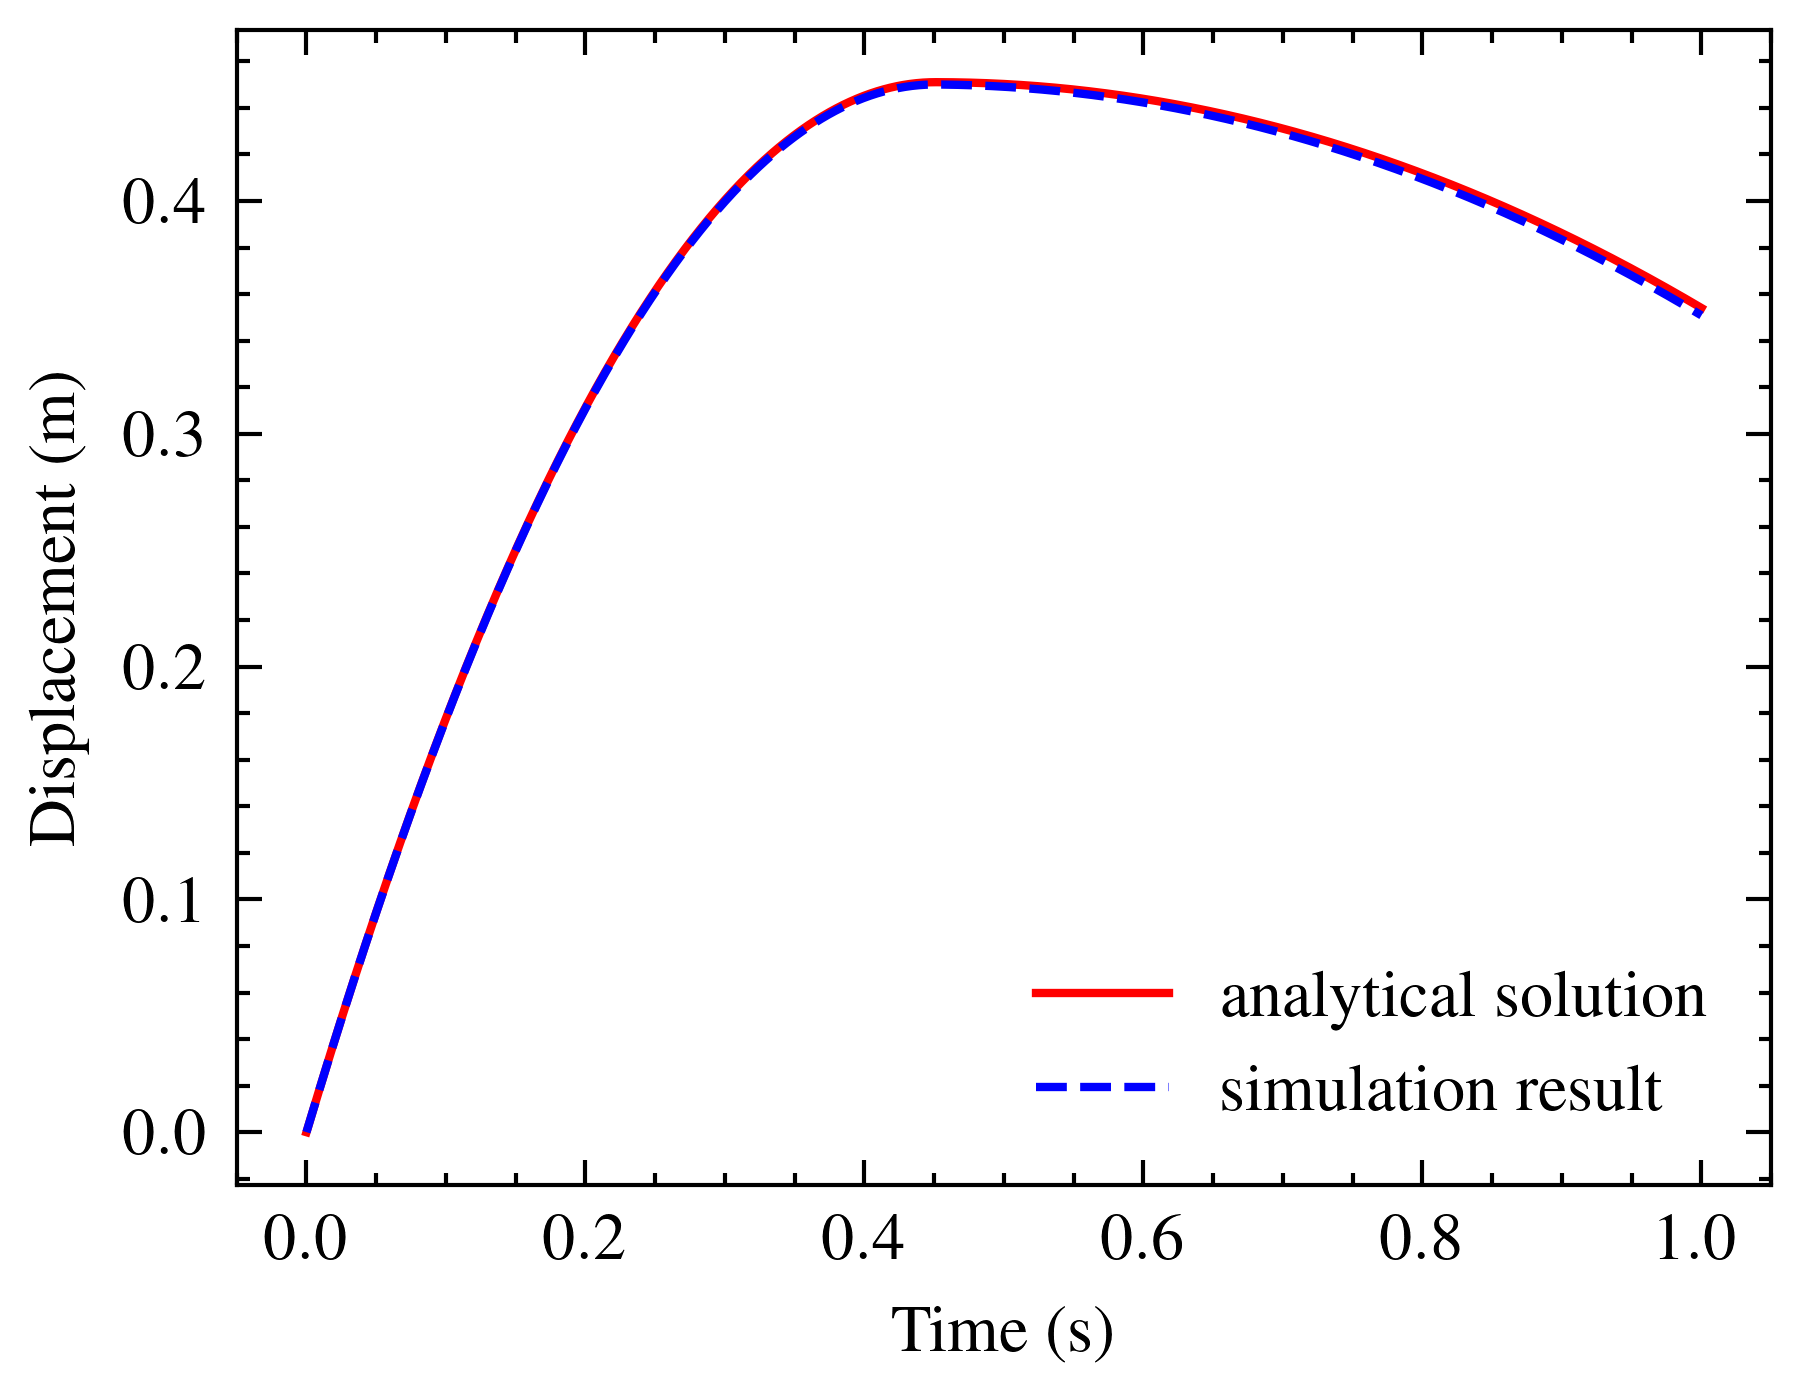

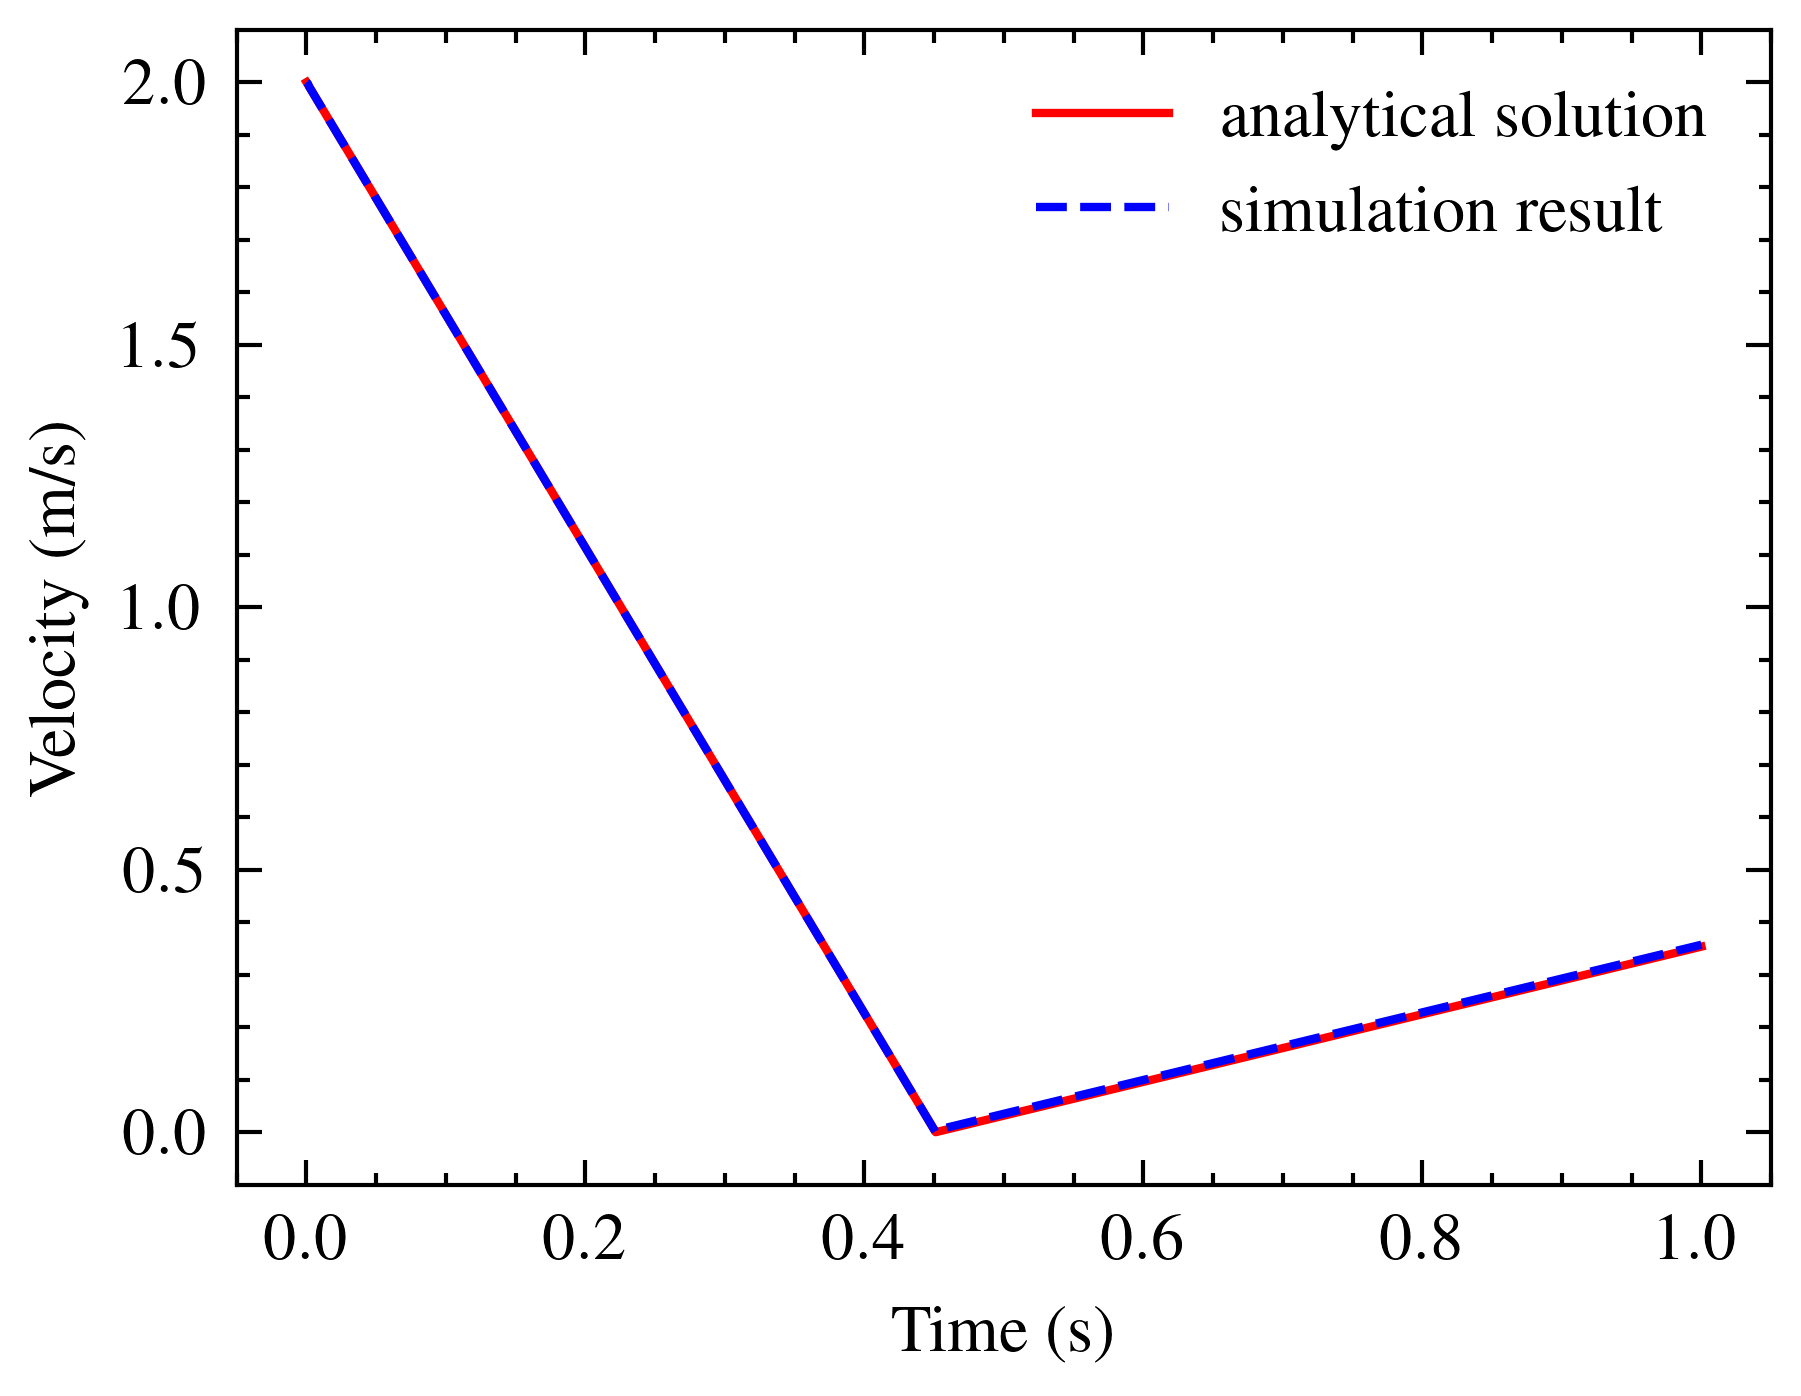

In [5]:
import numpy as np
plot_time = 1
timeIndices = result['timeIndex']
contactInfo = result["contactInfo"]
partpq = result["partPq"]
partvs = result["partVs"]
partas = result["partAs"]
dts = result["dts"]
x = []
y = []
yv = []

lowerBound = sire.binarySearch(timeIndices, 0)
upperBound = sire.binarySearch(timeIndices, 0 + plot_time)
print(timeIndices[lowerBound], timeIndices[lowerBound + 1])
for i in range(lowerBound, upperBound + 1):
  # print(i, timeIndices[i], dts[i], partpq[i][1], partvs[i][1], partas[i][1], contactInfo[i])
  x.append(timeIndices[i])
  pm = sire.pq2tfmatrix(partpq[i][1])
  yOffset = pm[1, 3]
  zOffset = pm[2, 3] - cube_pe[2]
  y.append(math.sqrt(yOffset ** 2 + zOffset ** 2))  # displacement along incline
  yv.append(math.sqrt(partvs[i][1][2] ** 2 + partvs[i][1][1]**2))  # speed along incline

# mu=0.2 < tan(15°)=0.268, box slides back downhill after stopping
a1 = 9.81 * math.sin(math.radians(15)) + 0.2 * 9.81 * math.cos(math.radians(15))  # uphill decel
a2 = 9.81 * math.sin(math.radians(15)) - 0.2 * 9.81 * math.cos(math.radians(15))  # downhill accel
t_stop = 2 / a1
x_stop = 2 * t_stop - 0.5 * a1 * t_stop ** 2

x2 = np.linspace(0, plot_time, 10000)
y2 = np.piecewise(x2, 
                 [x2 <= t_stop, x2 > t_stop], 
                 [lambda x: 2 * x - 0.5 * a1 * x ** 2,
                  lambda x: x_stop - 0.5 * a2 * (x - t_stop) ** 2])
with plt.style.context(['science','ieee']):
  plt.plot(x2, y2, color='red', linestyle="-", label="analytical solution")
  plt.plot(x, y, color='blue', linestyle="--", label="simulation result")
  plt.legend()
  plt.xlabel("Time (s)")
  plt.ylabel("Displacement (m)")
  # plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data2.pdf", format="pdf")
  plt.show()

  x1 = np.linspace(0, plot_time, 10000)
  y1 = np.piecewise(x1, 
                   [x1 < t_stop, x1 >= t_stop], 
                   [lambda x: 2 - a1 * x,
                    lambda x: a2 * (x - t_stop)])
  plt.plot(x1, y1, color='red', linestyle="-", label="analytical solution")
  plt.plot(x, yv, color='blue', linestyle="--", label="simulation result")
  plt.xlabel("Time (s)")
  plt.ylabel("Velocity (m/s)")
  plt.legend()
  plt.show()


  Sire Accuracy Metrics — Box Sliding on 15° Incline (mu=0.2)
  (mu < tan(15°)=0.268, box slides back downhill)

                                  — Full Trajectory (0 — 1.0s) —
                                    Displacement        Velocity
  --------------------------------------------------------------
  RMSE:                                 0.001657        0.002685
  MAE:                                  0.001368        0.001990
  Max absolute error:                   0.003165        0.003625
  R² score:                             0.999771        0.999978

                              — Turning Point (t_stop=0.4510s) —
  Analytical x_stop:                    0.451044 m
  Sire displacement at t_stop:          0.450046 m
  Absolute difference:                  0.000998 m
[0.00e+00 1.00e-03 2.00e-03 3.00e-03 4.00e-03 5.00e-03 6.00e-03 7.00e-03
 8.00e-03 9.00e-03 1.00e-02 1.10e-02 1.20e-02 1.30e-02 1.40e-02 1.50e-02
 1.60e-02 1.70e-02 1.80e-02 1.90e-02 2.00e-02 2.10e-02 2.20e-02 2.

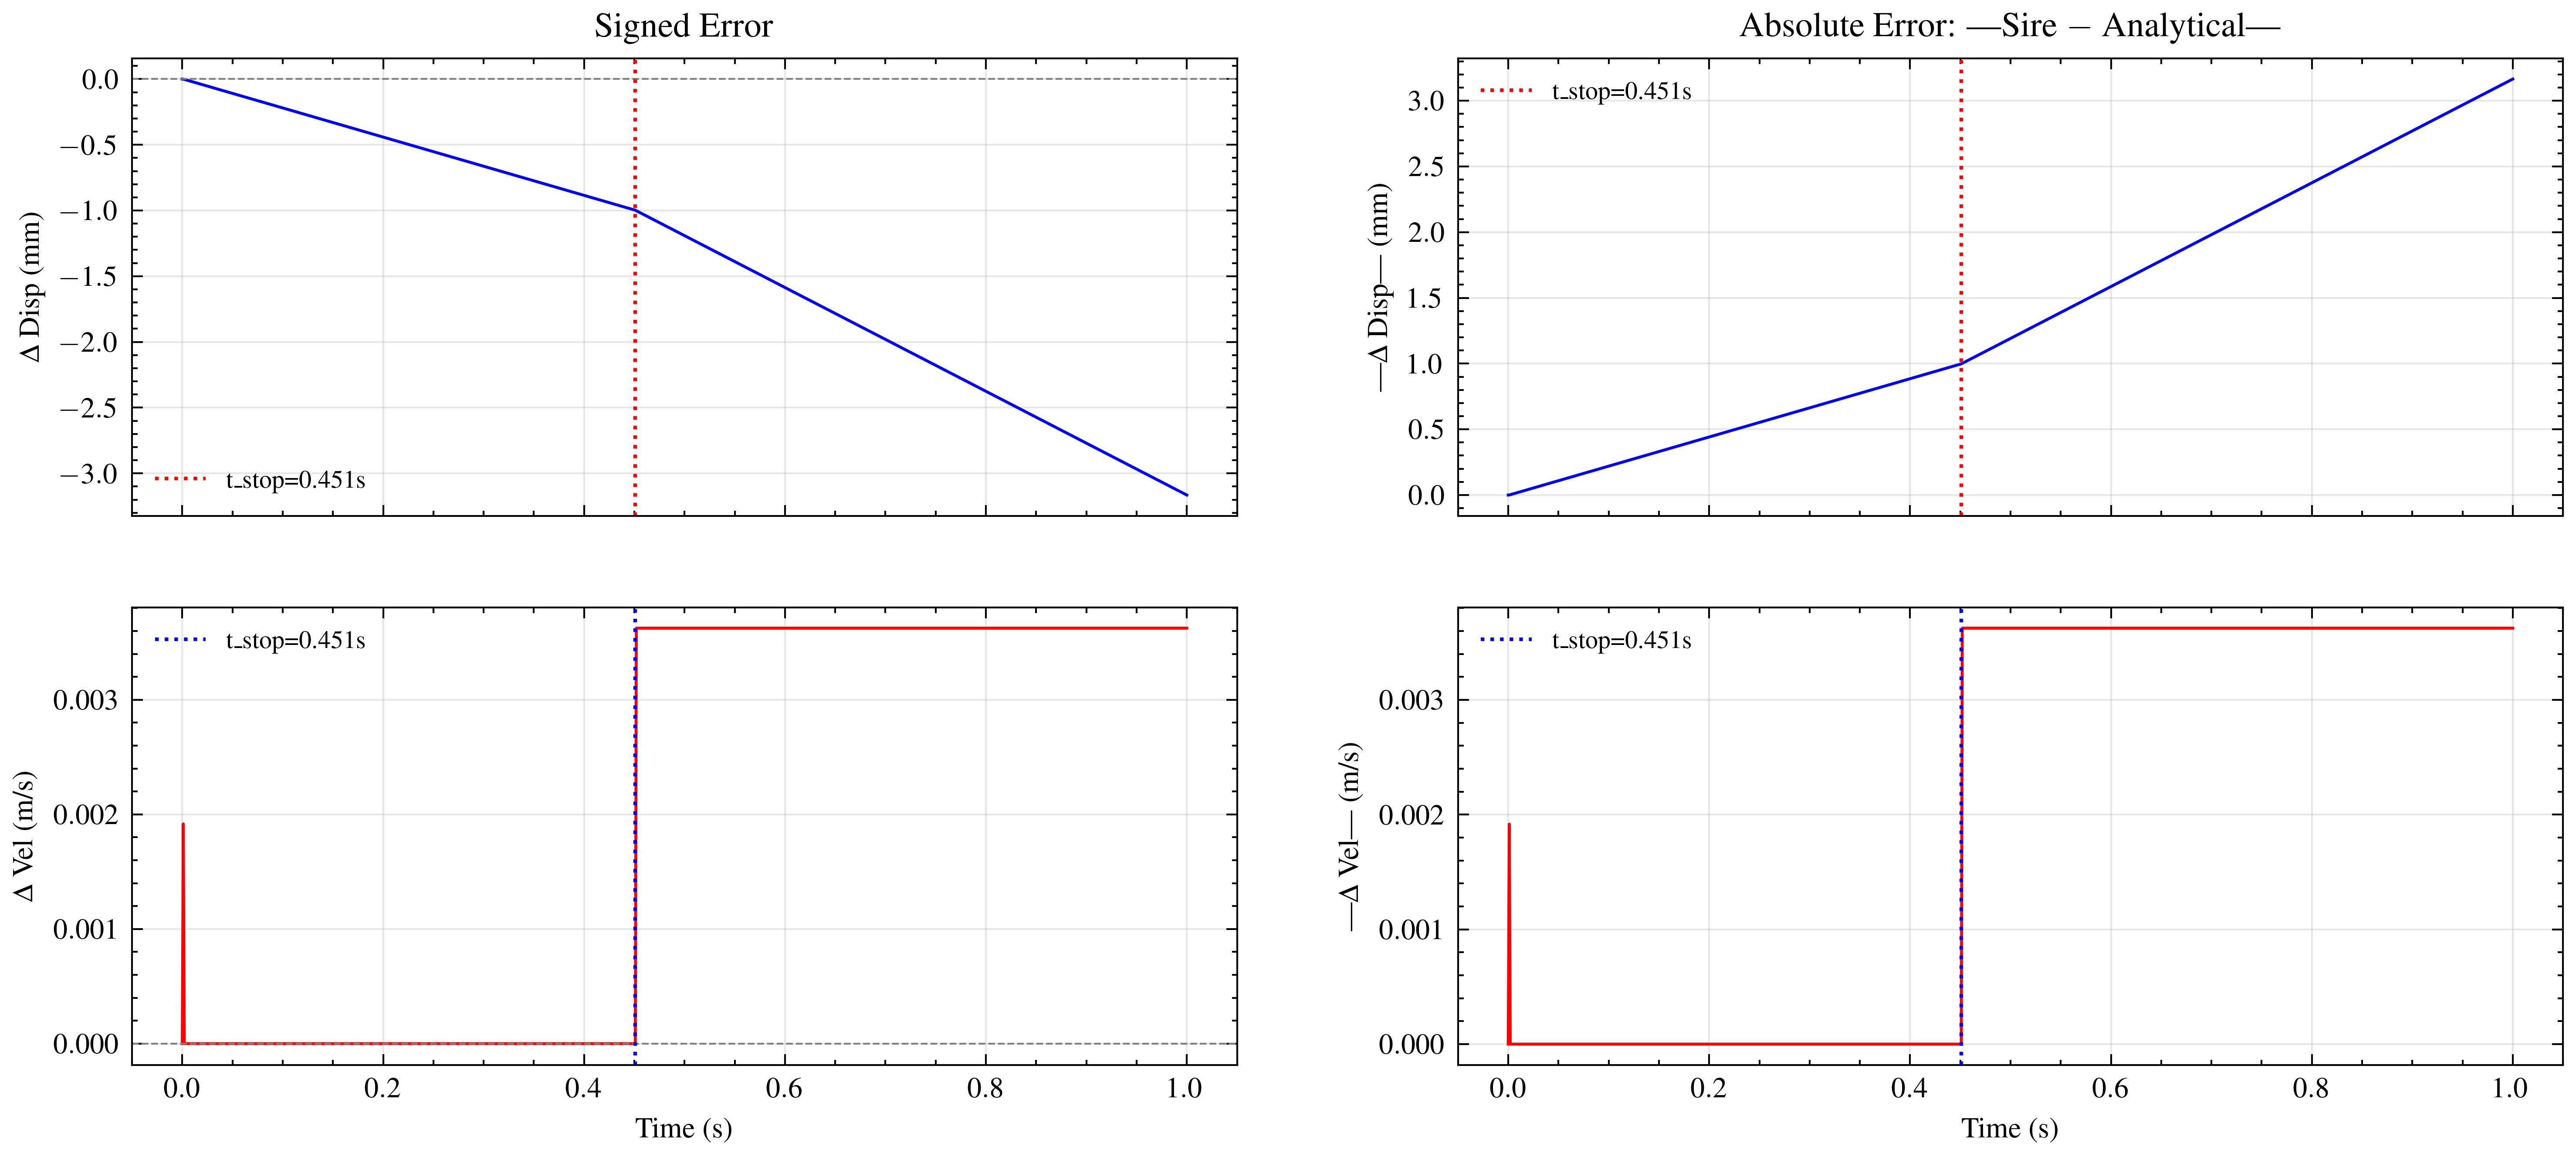

In [6]:
import numpy as np
import math
import matplotlib.pyplot as plt

# ======================== Parameters & Analytical ========================
angle_deg = 15
angle_rad = math.radians(angle_deg)
g = 9.81
mu = 0.2
v0 = 2.0
# mu < tan(15°), so after stopping uphill, box slides back downhill
a1 = g * math.sin(angle_rad) + mu * g * math.cos(angle_rad)  # uphill deceleration
a2 = g * math.sin(angle_rad) - mu * g * math.cos(angle_rad)  # downhill acceleration
t_stop = v0 / a1
x_stop = v0 * t_stop - 0.5 * a1 * t_stop**2

# ======================== Analytical curves (fine grid) ========================
t_ana = np.linspace(0, plot_time, 10000)
disp_ana = np.piecewise(t_ana,
                        [t_ana <= t_stop, t_ana > t_stop],
                        [lambda t: v0*t - 0.5*a1*t**2,
                         lambda t: x_stop - 0.5*a2*(t - t_stop)**2])
vel_ana = np.piecewise(t_ana,
                       [t_ana < t_stop, t_ana >= t_stop],
                       [lambda t: v0 - a1*t,
                        lambda t: a2*(t - t_stop)])

# Interpolate analytical onto sire time points
x_arr = np.array(x)
y_arr = np.array(y)
yv_arr = np.array(yv)

disp_ana_at_sire = np.interp(x_arr, t_ana, disp_ana)
vel_ana_at_sire = np.interp(x_arr, t_ana, vel_ana)

# ======================== Full-Trajectory Errors ========================
disp_error = y_arr - disp_ana_at_sire
vel_error = yv_arr - vel_ana_at_sire

disp_rmse_full = np.sqrt(np.mean(disp_error**2))
vel_rmse_full = np.sqrt(np.mean(vel_error**2))
disp_mae_full = np.mean(np.abs(disp_error))
vel_mae_full = np.mean(np.abs(vel_error))
disp_max_err = np.max(np.abs(disp_error))
vel_max_err = np.max(np.abs(vel_error))

ss_res_d = np.sum(disp_error**2)
ss_tot_d = np.sum((y_arr - np.mean(y_arr))**2)
r2_disp = 1 - ss_res_d / ss_tot_d if ss_tot_d > 1e-15 else 1.0

ss_res_v = np.sum(vel_error**2)
ss_tot_v = np.sum((yv_arr - np.mean(yv_arr))**2)
r2_vel = 1 - ss_res_v / ss_tot_v if ss_tot_v > 1e-15 else 1.0

# ======================== Turning-Point Error ========================
idx_stop = np.argmin(np.abs(x_arr - t_stop))
disp_at_stop = y_arr[idx_stop]
disp_stop_err = abs(disp_at_stop - x_stop)

# ======================== Print Results ========================
print(f"\n{'='*62}")
print(f"  Sire Accuracy Metrics — Box Sliding on {angle_deg}° Incline (mu={mu})")
print(f"{'='*62}")
print(f"  (mu < tan({angle_deg}°)={math.tan(angle_rad):.3f}, box slides back downhill)")

traj_label = f"— Full Trajectory (0 — {plot_time:.1f}s) —"
print(f"\n  {traj_label:>62}")
print(f"  {'':>30} {'Displacement':>15} {'Velocity':>15}")
print(f"  {'-'*62}")
print(f"  {'RMSE:':<30} {disp_rmse_full:>15.6f} {vel_rmse_full:>15.6f}")
print(f"  {'MAE:':<30} {disp_mae_full:>15.6f} {vel_mae_full:>15.6f}")
print(f"  {'Max absolute error:':<30} {disp_max_err:>15.6f} {vel_max_err:>15.6f}")
print(f"  {'R² score:':<30} {r2_disp:>15.6f} {r2_vel:>15.6f}")

turn_label = f"— Turning Point (t_stop={t_stop:.4f}s) —"
print(f"\n  {turn_label:>62}")
print(f"  {'Analytical x_stop:':<30} {x_stop:>15.6f} m")
print(f"  {'Sire displacement at t_stop:':<30} {disp_at_stop:>15.6f} m")
print(f"  {'Absolute difference:':<30} {disp_stop_err:>15.6f} m")
print(f"{'='*62}")

# ======================== Plots ========================
with plt.style.context(['science', 'ieee']):
    # --- Error-over-time (2x2: signed + absolute) ---
    fig, axes = plt.subplots(2, 2, figsize=(12, 5), sharex=True)

    axes[0, 0].plot(x_arr, disp_error * 1000, 'b-', linewidth=0.8)
    axes[0, 0].axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
    axes[0, 0].axvline(x=t_stop, color='r', linestyle=':', linewidth=1.0, label=f't_stop={t_stop:.3f}s')
    axes[0, 0].set_ylabel("$\\Delta$ Disp (mm)")
    axes[0, 0].set_title("Signed Error")
    axes[0, 0].legend(fontsize=7)
    axes[0, 0].grid(True, alpha=0.3)
    np.set_printoptions(threshold=np.inf)
    print(x_arr)
    print(disp_error)
    print(vel_error)

    axes[0, 1].plot(x_arr, np.abs(disp_error) * 1000, 'b-', linewidth=0.8)
    axes[0, 1].axvline(x=t_stop, color='r', linestyle=':', linewidth=1.0, label=f't_stop={t_stop:.3f}s')
    axes[0, 1].set_ylabel("|$\\Delta$ Disp| (mm)")
    axes[0, 1].set_title("Absolute Error: |Sire $-$ Analytical|")
    axes[0, 1].legend(fontsize=7)
    axes[0, 1].grid(True, alpha=0.3)

    axes[1, 0].plot(x_arr, vel_error, 'r-', linewidth=0.8)
    axes[1, 0].axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
    axes[1, 0].axvline(x=t_stop, color='b', linestyle=':', linewidth=1.0, label=f't_stop={t_stop:.3f}s')
    axes[1, 0].set_xlabel("Time (s)")
    axes[1, 0].set_ylabel("$\\Delta$ Vel (m/s)")
    axes[1, 0].legend(fontsize=7)
    axes[1, 0].grid(True, alpha=0.3)

    axes[1, 1].plot(x_arr, np.abs(vel_error), 'r-', linewidth=0.8)
    axes[1, 1].axvline(x=t_stop, color='b', linestyle=':', linewidth=1.0, label=f't_stop={t_stop:.3f}s')
    axes[1, 1].set_xlabel("Time (s)")
    axes[1, 1].set_ylabel("|$\\Delta$ Vel| (m/s)")
    axes[1, 1].legend(fontsize=7)
    axes[1, 1].grid(True, alpha=0.3)

    plt.show()

# Analytical implicit contact solver

In [7]:
import matplotlib.pyplot as plt
import scienceplots
import math
import numpy as np

def calculate_inclined_positions(angle_deg=15):
    """
    计算小方块在10度斜面上的位置
    
    参数:
    angle_deg: 斜面角度(度)
    """
    # 角度转换为弧度
    angle_rad = math.radians(angle_deg)
    
    # 当前参数
    ground_height = 0.5  # 地面几何中心z坐标
    ground_thickness = 1  # 地面厚度
    cube_size = 1         # 小方块尺寸
    
    # 计算斜面位置
    # 斜面绕x轴旋转10度，保持地面顶部与原点相切
    ground_pe = [0, 0, ground_height, 0, -angle_rad, 0]  # [x,y,z,rx,ry,rz]
    
    # 计算小方块位置
    # 小方块应该放在斜面上，底部四个小球与斜面接触
    cube_height = ground_height + (cube_size + ground_thickness) * 0.5 / math.cos(angle_rad)
    # cube_z_offset = sphere_radius + (cube_size/2 - 0.4)  # 考虑小球半径和几何偏移
    # cube_height = cube_z_offset + (cube_size/2) * math.sin(angle_rad)
    
    # 小方块的位置和姿态
    cube_pe = [0, 0, cube_height, 0, -angle_rad, 0]
    
    return ground_pe, cube_pe

  # import sys
  # sys.path.append("D:/code/sire/install/python/debug")
import sire
sim = sire.Simulator()
model = sim.model()
model.addSolvers()
simulator = sim.simulationLoop()
simulator.simDuration = 2
simulator.deltaT = 0.001
simulator.ctrlT = 10
simulator.setEventHandlerMap({0:9, 1:10, 2:11})
physicsEngine = sim.physicsEngine()
contactSolver = physicsEngine.addAnalyticalImplicitFrictionSolver()
physicsEngine.collisionDetectionFlag = True
physicsEngine.contactSolverFlag = True
contactSolver.setDefaultProp("{k:1.4e8,d:10000,cr:0.2}")
# contactSolver.setDefaultProp("{k:2e7,d:10000,cr:0.2}")
# contactSolver.addMaterialPair("m1", "m1", "{k:2e8,d:10000,cr:0,cof:0.3,threshold_velocity:2e-6}")
contactSolver.addMaterialPair("m1", "m2", "{k:2e8,d:150000,cr:0.2,cof:0.2,threshold_velocity:1e-5}")
model.setGravity([0, 0, -9.81, 0, 0, 0])
model.ground().addMarker("joint_0_k")
model.ground().addMarker("ground_marker")
ground_pe, cube_pe = calculate_inclined_positions(15)
# cube_pe[2] = 2
ground_pm = sire.pe3132tfmatrix(ground_pe).tolist()
model.ground().addBoxGeometry(0, 100, 100, 1, [1,0,0,0,0,1,0,0,0,0,1,-0.5,0,0,0,1])
model.ground().addBoxGeometry(0, 5, 5, 1, ground_pm)

physicsEngine.addBoxGeometry(100, 100, 1, 0, False, [1,0,0,0,0,1,0,0,0,0,1,-0.5,0,0,0,1])
physicsEngine.addBoxGeometry(5, 5, 1, 0, False, ground_pm)
# sliderPrt = model.addPartByPe(ground_pe, "313", [10, 0, 0, 0, 0.1, 0.1, 0.1, 0, 0, 0])
# model.link(1).addMarker("slider_center")
boxPrt = model.addPartByPe(cube_pe, "313", [1, 0, 0, 0, 0.1, 0.1, 0.1, 0, 0, 0])
model.link(1).addMarker("box_center")
model.init()
boxPrt.addBoxGeometry(boxPrt.id, 1.0, 1.0, 1.0, prt_pm=[1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1])
boxPrt.cptGeometryInertial2Part(1)
boxPrt.vs = sire.vp2vs(cube_pe[:3], [0, -2 * math.cos(math.radians(15)), 2 * math.sin(math.radians(15))])

physicsEngine.addBoxGeometry(1, 1, 1, boxPrt.id, True)
physicsEngine.addSphereGeometry(0.1, boxPrt.id, True, [1,0,0,0.5,0,1,0,0.5,0,0,1,-0.4,0,0,0,1], material="m2")
physicsEngine.addSphereGeometry(0.1, boxPrt.id, True, [1,0,0,0.5,0,1,0,-0.5,0,0,1,-0.4,0,0,0,1], material="m2")
physicsEngine.addSphereGeometry(0.1, boxPrt.id, True, [1,0,0,-0.5,0,1,0,0.5,0,0,1,-0.4,0,0,0,1], material="m2")
physicsEngine.addSphereGeometry(0.1, boxPrt.id, True, [1,0,0,-0.5,0,1,0,-0.5,0,0,1,-0.4,0,0,0,1], material="m2")
# print(sire.toXmlString(sim))
sim.init()
for i in range(4):
  physicsEngine.collisionFilter().enableCollisionPair(1, i + 3)

physicsEngine.collisionFilter().saveMatConfig()
print(sire.toXmlString(sim))

count = 0
while(not simulator.isTimeout() and not simulator.isEventListEmpty()):
  sim_time = simulator.simTime()
  # if abs(sim_time - 0.37) < 1e-8 and count == 0:
  #   print(boxPrt.getAs())
  #   count += 1
  simulator.step(1, False)

simulator.recordsContactCptInfo()
displayInitJson = model.displayInitJson()
result = simulator.recordsToJson()

# pltResult = result
# timeIndices = pltResult['timeIndex']
# pp = pltResult["penetrationPairs"]  # contactInfo is renamed to penetrationPairs in the latest code
# partpq = pltResult["partPq"]
# partvs = pltResult["partVs"]
# partas = pltResult["partAs"]
# gf = pltResult["generalForces"]
# dts = pltResult["dts"]
# x = []
# y = []
# yv = []
# # print(result[i][2])

# lowerBound = sire.binarySearch(timeIndices, 0.16)
# upperBound = sire.binarySearch(timeIndices, 0.198)
# print(lowerBound, upperBound)
# # with open('hfield_data.txt', 'w') as f:          # 'w' 覆盖写，'a' 追加写
# # with open('box_data.txt', 'w') as f:          # 'w' 覆盖写，'a' 追加写
# for j in range(lowerBound, upperBound):
#     # print(j, f"{timeIndices[j]:.4f}", f"{dts[j]:.4f}", f"{partpq[j][1][2]:.6f}", f"{partvs[j][1][2]:.6f}", f"{partas[j][1][2]:.6f}", pp[j], gf[j], file=f)
#   print(j, f"{timeIndices[j]:.4f}", f"{dts[j]:.4f}", f"{partpq[j][1][2]:.6f}", f"{partvs[j][1][2]:.6f}", f"{partas[j][1][2]:.6f}", pp[j], gf[j])

print("Simulation finished, records loaded")
import meshcat
vis = meshcat.Visualizer()
resourcePath = "D:/code/sire/web_interface/public"
sire.robotInit(model.numLinks(), resourcePath, displayInitJson, vis)
sire.animateRobotByRecords(model.numLinks(), result, 1000, vis)
# cs.clear()
vis.jupyter_cell()

<Simulator>
    <Model __prop_name__="model" name="object" time="0">
        <Environment __prop_name__="environment" gravity="{0,0,-9.81,0,0,0}"/>
        <VariablePoolElement __prop_name__="variable_pool"/>
        <PartPoolElement __prop_name__="part_pool">
            <Part name="ground" active="true" pe="{0,0,0,-0,0,-0}" vel="{0,0,0,0,0,0}" acc="{0,0,0,0,0,0}" inertia="{1,0,0,0,1,1,1,0,0,0}">
                <MarkerPoolElement __prop_name__="marker_pool">
                    <Marker name="joint_0_k" active="true" pe="{0,0,0,-0,0,-0}"/>
                    <Marker name="ground_marker" active="true" pe="{0,0,0,-0,0,-0}"/>
                </MarkerPoolElement>
                <GeometryPoolElement __prop_name__="geometry_pool">
                    <BoxGeometry id="0" pm="{1,0,0,0,0,1,0,0,0,0,1,-0.5,0,0,0,1}" part_id="0" is_dynamic="true" side="{100,100,1}"/>
                    <BoxGeometry id="1" pm="{1,-0,0,0,0,0.965925826289068,0.258819045102521,0,-0,-0.258819045102521,0.96592582628

0.0 0.001


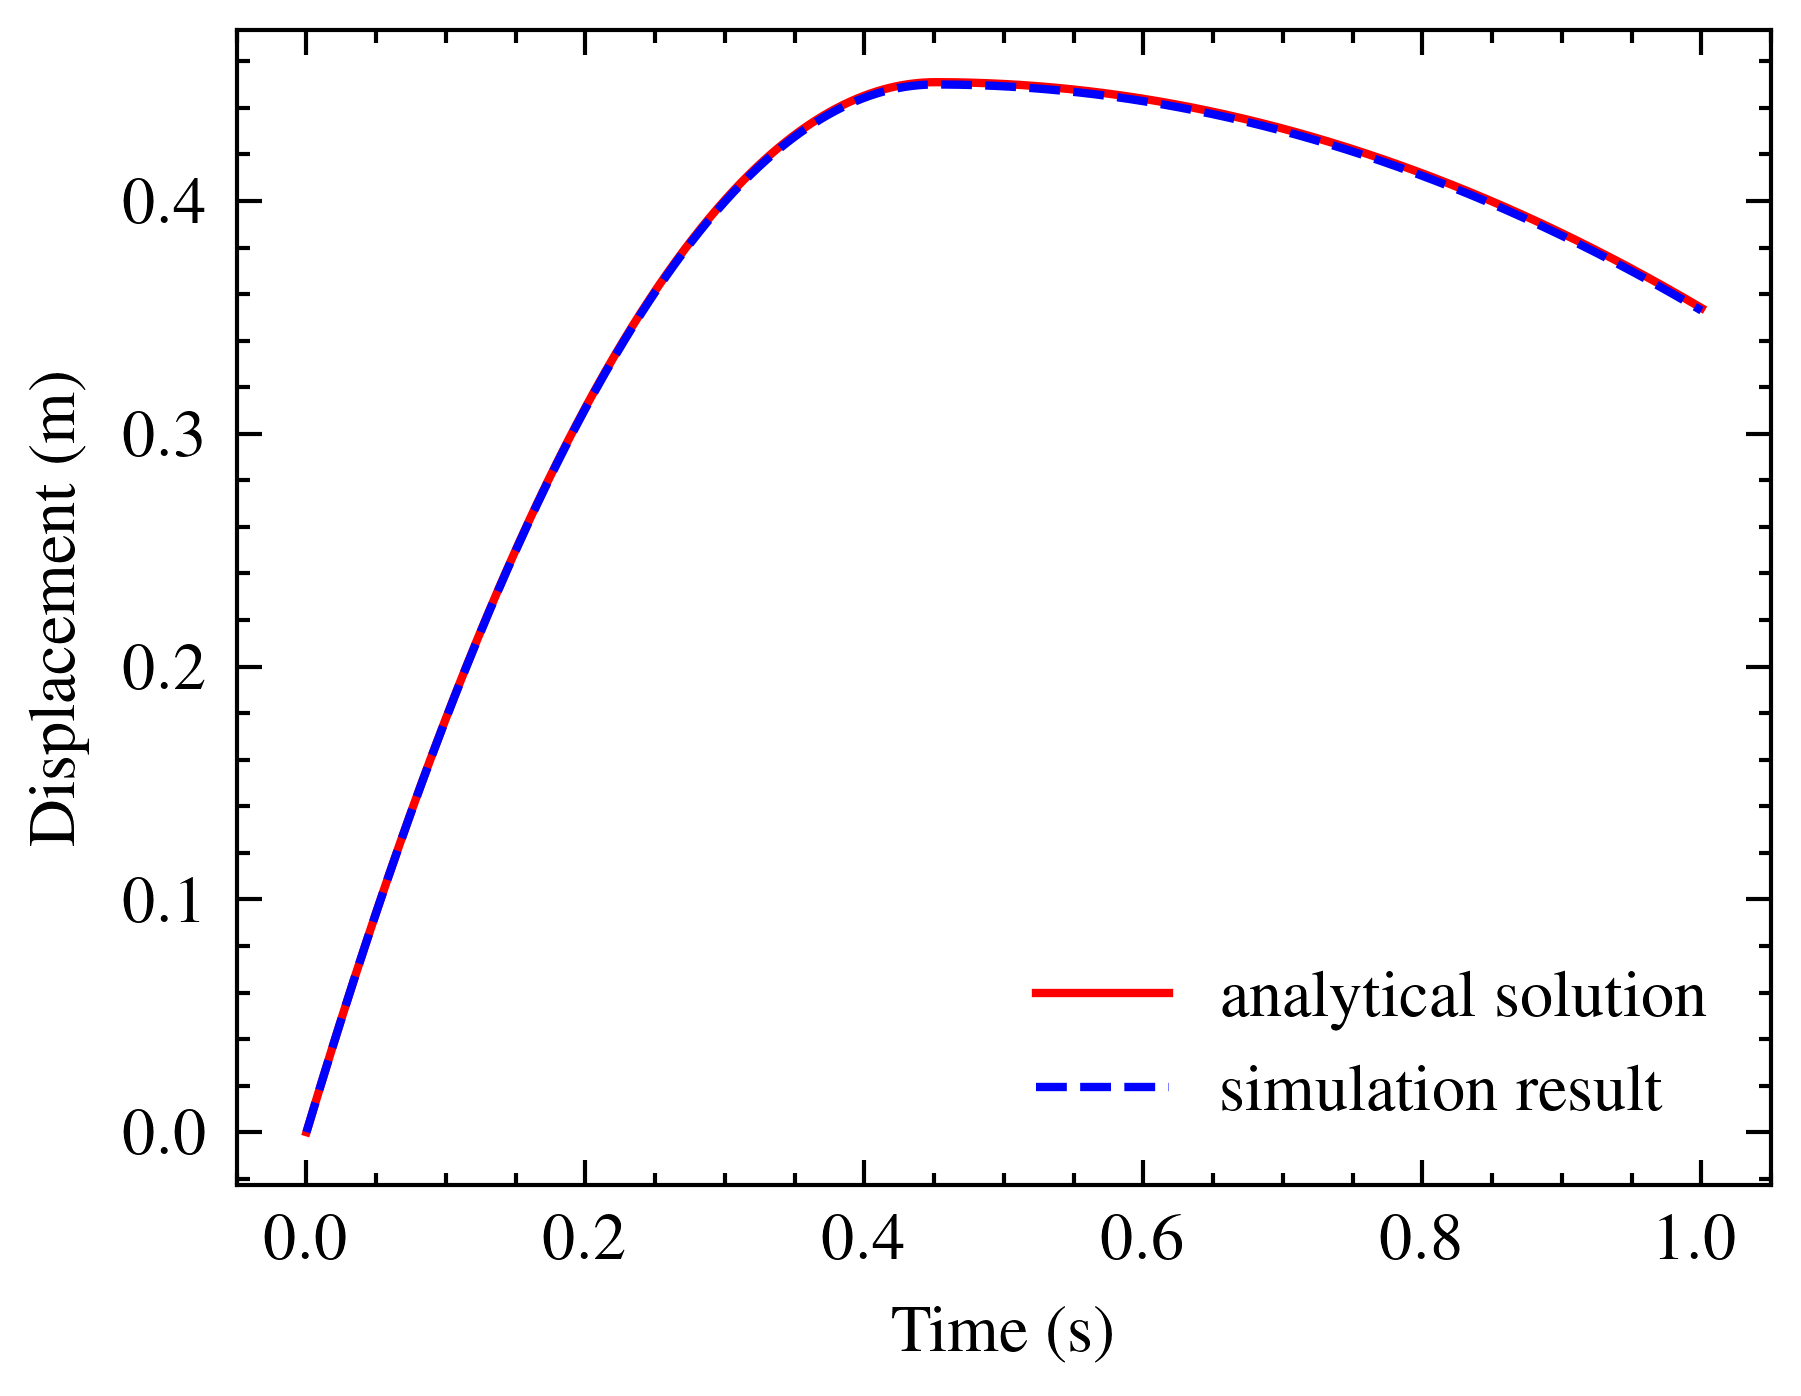

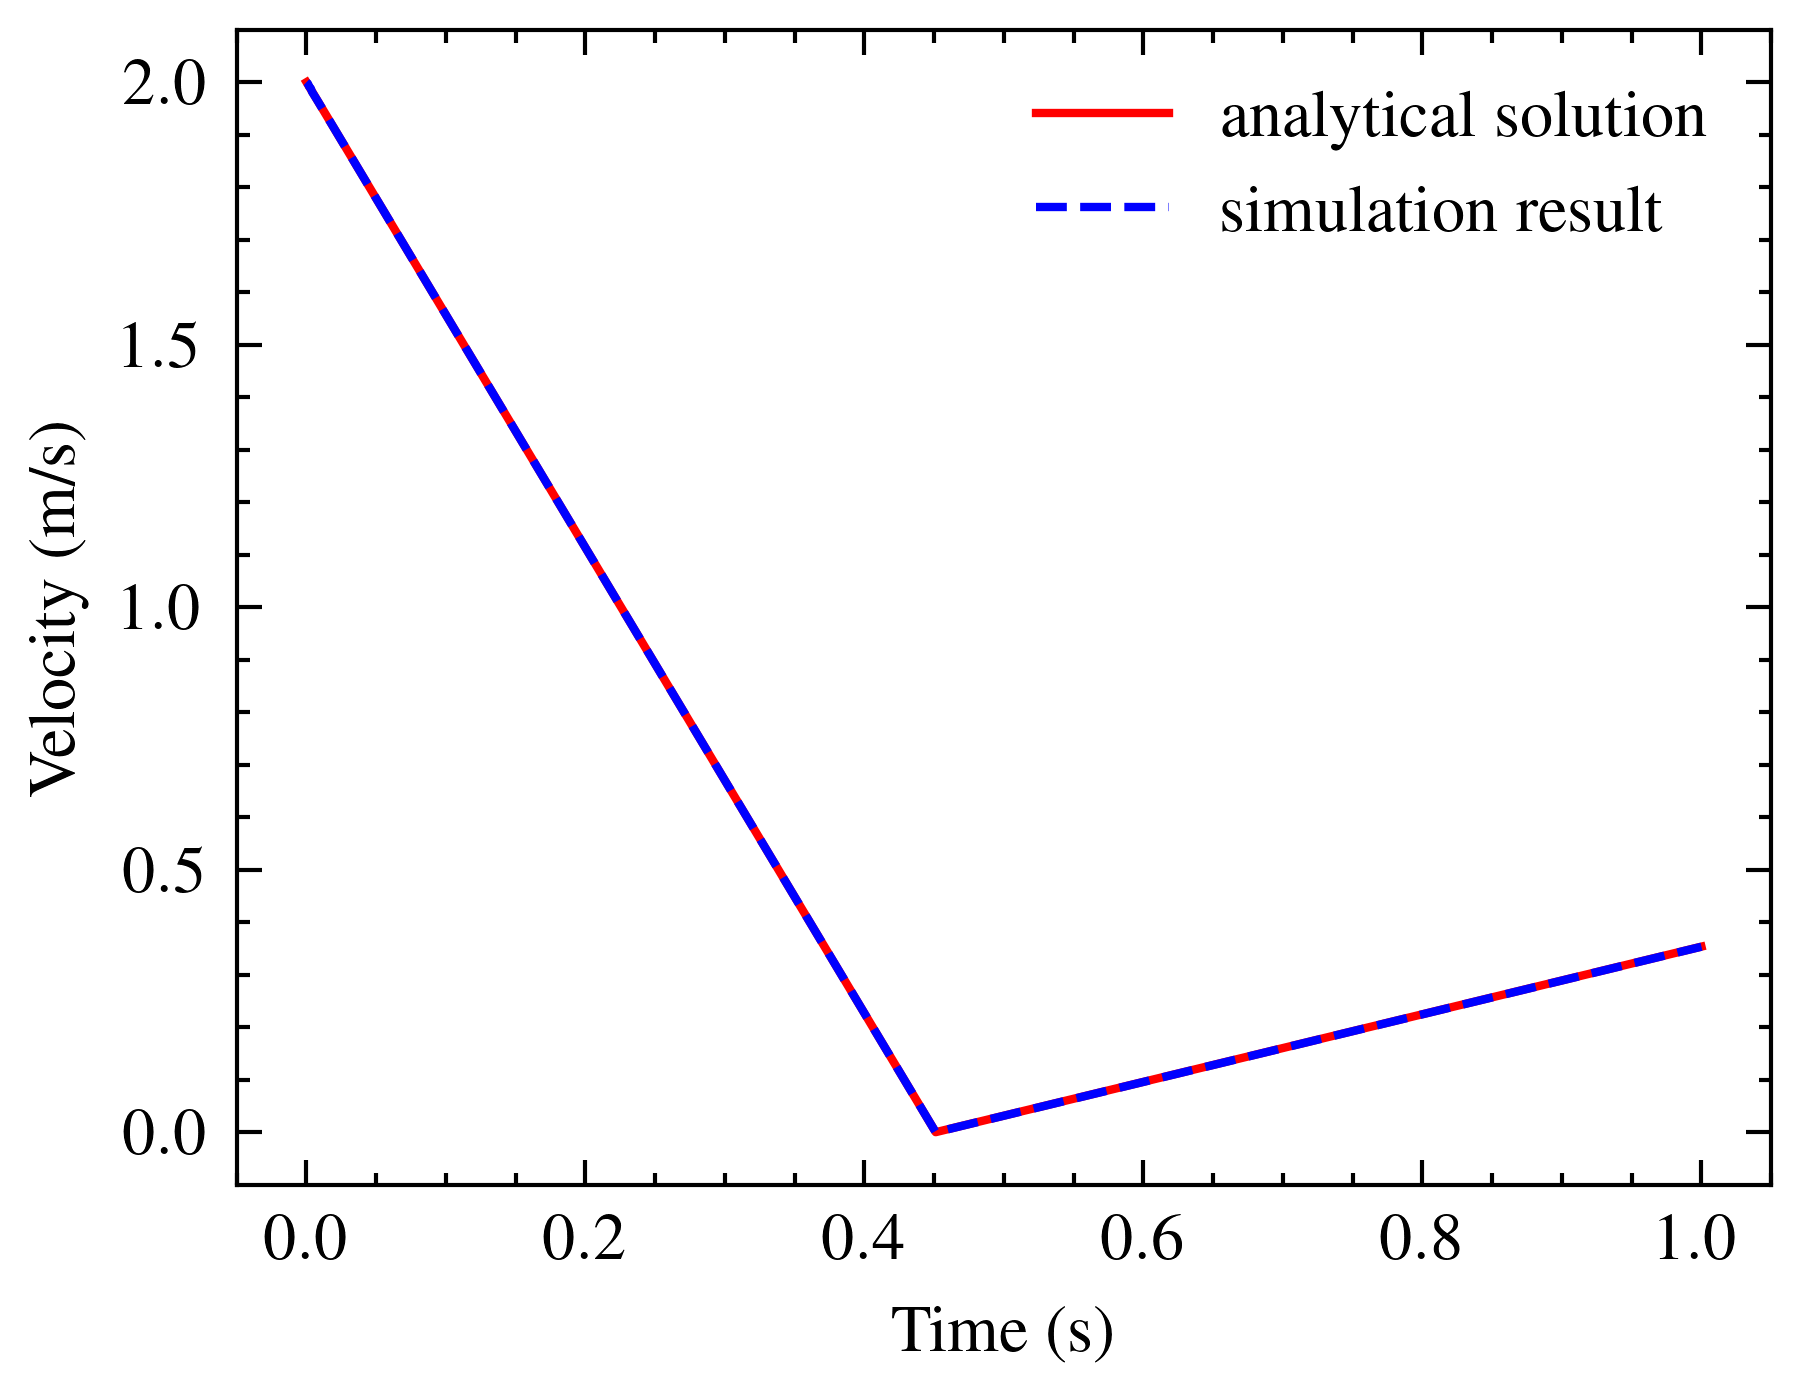

In [8]:
import numpy as np
plot_time = 1
timeIndices = result['timeIndex']
contactInfo = result["contactInfo"]
partpq = result["partPq"]
partvs = result["partVs"]
partas = result["partAs"]
dts = result["dts"]
x = []
y = []
yv = []

lowerBound = sire.binarySearch(timeIndices, 0)
upperBound = sire.binarySearch(timeIndices, 0 + plot_time)
print(timeIndices[lowerBound], timeIndices[lowerBound + 1])
for i in range(lowerBound, upperBound + 1):
  # print(i, timeIndices[i], dts[i], partpq[i][1], partvs[i][1], partas[i][1], contactInfo[i])
  x.append(timeIndices[i])
  pm = sire.pq2tfmatrix(partpq[i][1])
  yOffset = pm[1, 3]
  zOffset = pm[2, 3] - cube_pe[2]
  y.append(math.sqrt(yOffset ** 2 + zOffset ** 2))  # displacement along incline
  yv.append(math.sqrt(partvs[i][1][2] ** 2 + partvs[i][1][1]**2))  # speed along incline

# mu=0.2 < tan(15°)=0.268, box slides back downhill after stopping
a1 = 9.81 * math.sin(math.radians(15)) + 0.2 * 9.81 * math.cos(math.radians(15))  # uphill decel
a2 = 9.81 * math.sin(math.radians(15)) - 0.2 * 9.81 * math.cos(math.radians(15))  # downhill accel
t_stop = 2 / a1
x_stop = 2 * t_stop - 0.5 * a1 * t_stop ** 2

x2 = np.linspace(0, plot_time, 10000)
y2 = np.piecewise(x2, 
                 [x2 <= t_stop, x2 > t_stop], 
                 [lambda x: 2 * x - 0.5 * a1 * x ** 2,
                  lambda x: x_stop - 0.5 * a2 * (x - t_stop) ** 2])
with plt.style.context(['science','ieee']):
  plt.plot(x2, y2, color='red', linestyle="-", label="analytical solution")
  plt.plot(x, y, color='blue', linestyle="--", label="simulation result")
  plt.legend()
  plt.xlabel("Time (s)")
  plt.ylabel("Displacement (m)")
  # plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data2.pdf", format="pdf")
  plt.show()

  x1 = np.linspace(0, plot_time, 10000)
  y1 = np.piecewise(x1, 
                   [x1 < t_stop, x1 >= t_stop], 
                   [lambda x: 2 - a1 * x,
                    lambda x: a2 * (x - t_stop)])
  plt.plot(x1, y1, color='red', linestyle="-", label="analytical solution")
  plt.plot(x, yv, color='blue', linestyle="--", label="simulation result")
  plt.xlabel("Time (s)")
  plt.ylabel("Velocity (m/s)")
  plt.legend()
  plt.show()


  Sire Accuracy Metrics — Box Sliding on 15° Incline (mu=0.2)
  (mu < tan(15°)=0.268, box slides back downhill)

                                  — Full Trajectory (0 — 1.0s) —
                                    Displacement        Velocity
  --------------------------------------------------------------
  RMSE:                                 0.000863        0.000152
  MAE:                                  0.000796        0.000096
  Max absolute error:                   0.001084        0.001918
  R² score:                             0.999938        1.000000

                              — Turning Point (t_stop=0.4510s) —
  Analytical x_stop:                    0.451044 m
  Sire displacement at t_stop:          0.450046 m
  Absolute difference:                  0.000998 m
[0.00e+00 1.00e-03 2.00e-03 3.00e-03 4.00e-03 5.00e-03 6.00e-03 7.00e-03
 8.00e-03 9.00e-03 1.00e-02 1.10e-02 1.20e-02 1.30e-02 1.40e-02 1.50e-02
 1.60e-02 1.70e-02 1.80e-02 1.90e-02 2.00e-02 2.10e-02 2.20e-02 2.

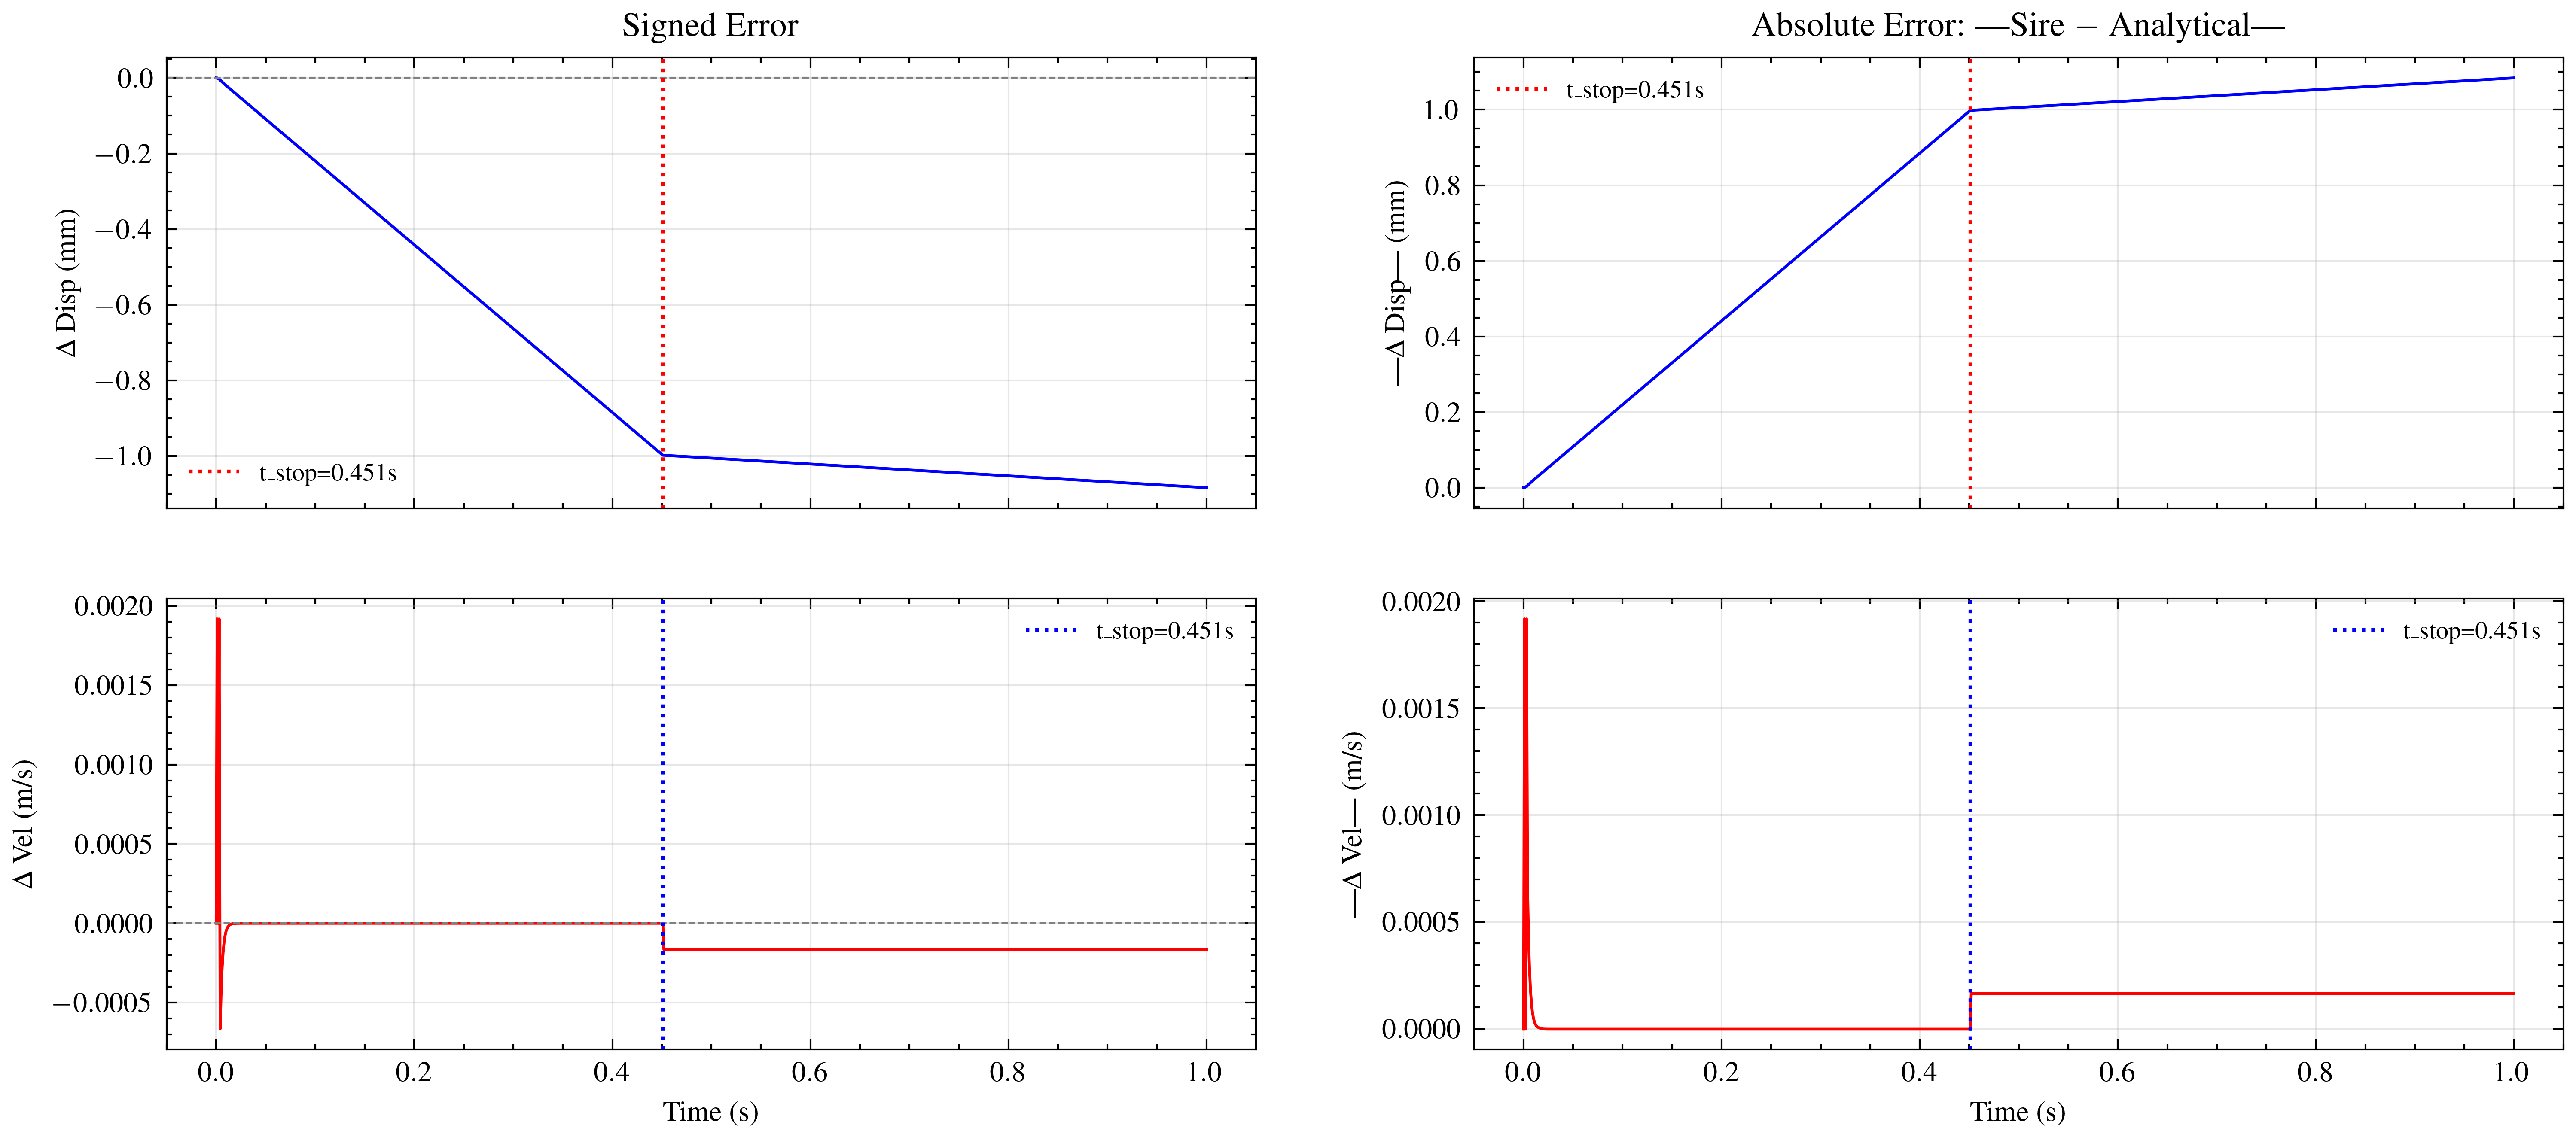

In [9]:
import numpy as np
import math
import matplotlib.pyplot as plt

# ======================== Parameters & Analytical ========================
angle_deg = 15
angle_rad = math.radians(angle_deg)
g = 9.81
mu = 0.2
v0 = 2.0
# mu < tan(15°), so after stopping uphill, box slides back downhill
a1 = g * math.sin(angle_rad) + mu * g * math.cos(angle_rad)  # uphill deceleration
a2 = g * math.sin(angle_rad) - mu * g * math.cos(angle_rad)  # downhill acceleration
t_stop = v0 / a1
x_stop = v0 * t_stop - 0.5 * a1 * t_stop**2

# ======================== Analytical curves (fine grid) ========================
t_ana = np.linspace(0, plot_time, 10000)
disp_ana = np.piecewise(t_ana,
                        [t_ana <= t_stop, t_ana > t_stop],
                        [lambda t: v0*t - 0.5*a1*t**2,
                         lambda t: x_stop - 0.5*a2*(t - t_stop)**2])
vel_ana = np.piecewise(t_ana,
                       [t_ana < t_stop, t_ana >= t_stop],
                       [lambda t: v0 - a1*t,
                        lambda t: a2*(t - t_stop)])

# Interpolate analytical onto sire time points
x_arr = np.array(x)
y_arr = np.array(y)
yv_arr = np.array(yv)

disp_ana_at_sire = np.interp(x_arr, t_ana, disp_ana)
vel_ana_at_sire = np.interp(x_arr, t_ana, vel_ana)

# ======================== Full-Trajectory Errors ========================
disp_error = y_arr - disp_ana_at_sire
vel_error = yv_arr - vel_ana_at_sire

disp_rmse_full = np.sqrt(np.mean(disp_error**2))
vel_rmse_full = np.sqrt(np.mean(vel_error**2))
disp_mae_full = np.mean(np.abs(disp_error))
vel_mae_full = np.mean(np.abs(vel_error))
disp_max_err = np.max(np.abs(disp_error))
vel_max_err = np.max(np.abs(vel_error))

ss_res_d = np.sum(disp_error**2)
ss_tot_d = np.sum((y_arr - np.mean(y_arr))**2)
r2_disp = 1 - ss_res_d / ss_tot_d if ss_tot_d > 1e-15 else 1.0

ss_res_v = np.sum(vel_error**2)
ss_tot_v = np.sum((yv_arr - np.mean(yv_arr))**2)
r2_vel = 1 - ss_res_v / ss_tot_v if ss_tot_v > 1e-15 else 1.0

# ======================== Turning-Point Error ========================
idx_stop = np.argmin(np.abs(x_arr - t_stop))
disp_at_stop = y_arr[idx_stop]
disp_stop_err = abs(disp_at_stop - x_stop)

# ======================== Print Results ========================
print(f"\n{'='*62}")
print(f"  Sire Accuracy Metrics — Box Sliding on {angle_deg}° Incline (mu={mu})")
print(f"{'='*62}")
print(f"  (mu < tan({angle_deg}°)={math.tan(angle_rad):.3f}, box slides back downhill)")

traj_label = f"— Full Trajectory (0 — {plot_time:.1f}s) —"
print(f"\n  {traj_label:>62}")
print(f"  {'':>30} {'Displacement':>15} {'Velocity':>15}")
print(f"  {'-'*62}")
print(f"  {'RMSE:':<30} {disp_rmse_full:>15.6f} {vel_rmse_full:>15.6f}")
print(f"  {'MAE:':<30} {disp_mae_full:>15.6f} {vel_mae_full:>15.6f}")
print(f"  {'Max absolute error:':<30} {disp_max_err:>15.6f} {vel_max_err:>15.6f}")
print(f"  {'R² score:':<30} {r2_disp:>15.6f} {r2_vel:>15.6f}")

turn_label = f"— Turning Point (t_stop={t_stop:.4f}s) —"
print(f"\n  {turn_label:>62}")
print(f"  {'Analytical x_stop:':<30} {x_stop:>15.6f} m")
print(f"  {'Sire displacement at t_stop:':<30} {disp_at_stop:>15.6f} m")
print(f"  {'Absolute difference:':<30} {disp_stop_err:>15.6f} m")
print(f"{'='*62}")

# ======================== Plots ========================
with plt.style.context(['science', 'ieee']):
    # --- Error-over-time (2x2: signed + absolute) ---
    fig, axes = plt.subplots(2, 2, figsize=(12, 5), sharex=True)

    axes[0, 0].plot(x_arr, disp_error * 1000, 'b-', linewidth=0.8)
    axes[0, 0].axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
    axes[0, 0].axvline(x=t_stop, color='r', linestyle=':', linewidth=1.0, label=f't_stop={t_stop:.3f}s')
    axes[0, 0].set_ylabel("$\\Delta$ Disp (mm)")
    axes[0, 0].set_title("Signed Error")
    axes[0, 0].legend(fontsize=7)
    axes[0, 0].grid(True, alpha=0.3)
    np.set_printoptions(threshold=np.inf)
    print(x_arr)
    print(disp_error)
    print(vel_error)

    axes[0, 1].plot(x_arr, np.abs(disp_error) * 1000, 'b-', linewidth=0.8)
    axes[0, 1].axvline(x=t_stop, color='r', linestyle=':', linewidth=1.0, label=f't_stop={t_stop:.3f}s')
    axes[0, 1].set_ylabel("|$\\Delta$ Disp| (mm)")
    axes[0, 1].set_title("Absolute Error: |Sire $-$ Analytical|")
    axes[0, 1].legend(fontsize=7)
    axes[0, 1].grid(True, alpha=0.3)

    axes[1, 0].plot(x_arr, vel_error, 'r-', linewidth=0.8)
    axes[1, 0].axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
    axes[1, 0].axvline(x=t_stop, color='b', linestyle=':', linewidth=1.0, label=f't_stop={t_stop:.3f}s')
    axes[1, 0].set_xlabel("Time (s)")
    axes[1, 0].set_ylabel("$\\Delta$ Vel (m/s)")
    axes[1, 0].legend(fontsize=7)
    axes[1, 0].grid(True, alpha=0.3)

    axes[1, 1].plot(x_arr, np.abs(vel_error), 'r-', linewidth=0.8)
    axes[1, 1].axvline(x=t_stop, color='b', linestyle=':', linewidth=1.0, label=f't_stop={t_stop:.3f}s')
    axes[1, 1].set_xlabel("Time (s)")
    axes[1, 1].set_ylabel("|$\\Delta$ Vel| (m/s)")
    axes[1, 1].legend(fontsize=7)
    axes[1, 1].grid(True, alpha=0.3)

    plt.show()

  Box Sliding on 15° Incline — MuJoCo Simulation
  Gravity:          9.81 m/s²
  Friction (μ):     0.2  (< tan(15°)=0.268)
  Initial velocity: 2.0 m/s (uphill)
  Uphill decel a1:  4.4342 m/s²
  Downhill accel a2:0.6439 m/s²
  Analytical stop:  t = 0.4510 s,  x = 0.4510 m
  Ramp center z:    0.5000 m
  Cube center z:    1.5363 m
  Initial velocity:  0 (box at rest, press ENTER in viewer to start)
Data collected: 1000 steps, dt = 0.001000s


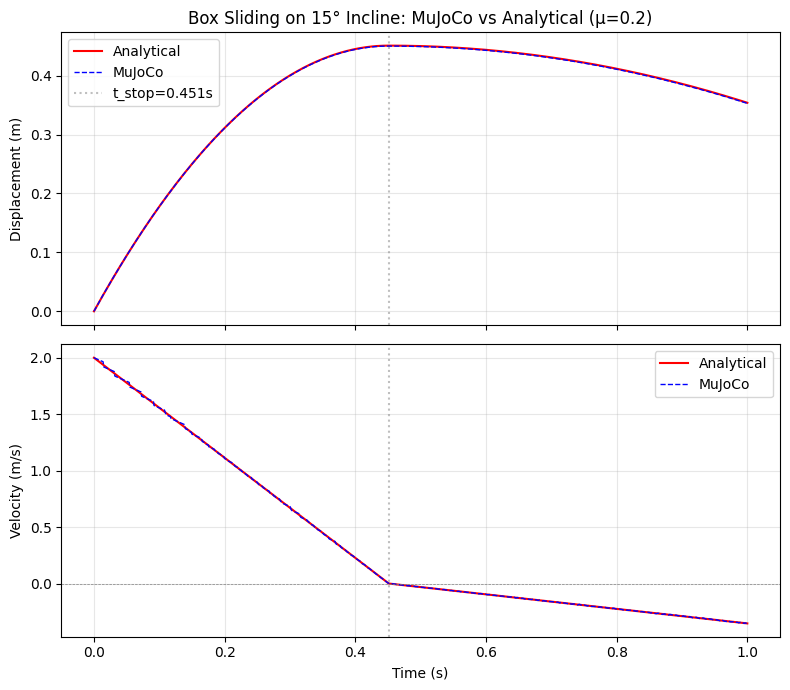


  Accuracy Metrics — MuJoCo vs Analytical (μ=0.2)
  (μ < tan(15°)=0.268, box slides back downhill)

                                  — Full Trajectory (0 — 1.0s) —
                                    Displacement        Velocity
  --------------------------------------------------------------
  RMSE:                                 0.000740        0.005002
  MAE:                                  0.000662        0.003096
  Max absolute error:                   0.001050        0.026532
  R² score:                             0.999955        0.999950

                              — Turning Point (t_stop=0.4510s) —
  Analytical x_stop:                    0.451044 m
  MuJoCo displacement at t_stop:        0.450241 m
  Absolute difference:                  0.000803 m
[0.    0.001 0.002 0.003 0.004 0.005 0.006 0.007 0.008 0.009 0.01  0.011
 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02  0.021 0.022 0.023
 0.024 0.025 0.026 0.027 0.028 0.029 0.03  0.031 0.032 0.033 0.034 0.035
 0.036

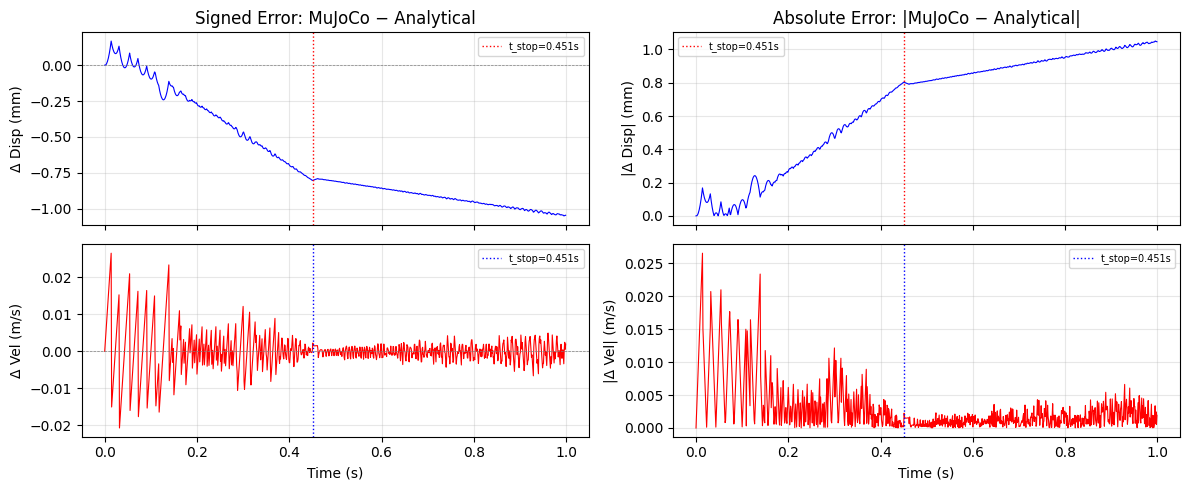

In [6]:
"""
MuJoCo Simulation: Box Sliding on 15° Inclined Plane
=====================================================
A 1×1×1m box slides on a 15° incline with μ=0.2 (< tan(15°)=0.268).
Initial velocity: 2 m/s uphill, then slides back downhill after stopping.

Run: python mujocoBoxSliding.py
Requires: pip install mujoco matplotlib numpy
"""

import mujoco
import numpy as np
import math
import matplotlib.pyplot as plt
import mujoco.viewer

# ======================== Parameters ========================
angle_deg = 15
angle_rad = math.radians(angle_deg)
g = 9.81
mu = 0.2        # friction coefficient (< tan(15°) → slides back)
v0 = 2.0        # initial velocity (m/s) uphill
dt = 0.001      # simulation timestep (s)

# ======================== Analytical Solution ========================
# Phase 1: uphill deceleration (gravity + friction oppose motion)
a1 = g * math.sin(angle_rad) + mu * g * math.cos(angle_rad)
# Phase 2: after stopping, slides back downhill (gravity wins over friction)
a2 = g * math.sin(angle_rad) - mu * g * math.cos(angle_rad)
t_stop = v0 / a1
x_stop = v0 * t_stop - 0.5 * a1 * t_stop**2

print(f"{'='*50}")
print(f"  Box Sliding on {angle_deg}° Incline — MuJoCo Simulation")
print(f"{'='*50}")
print(f"  Gravity:          {g} m/s²")
print(f"  Friction (μ):     {mu}  (< tan({angle_deg}°)={math.tan(angle_rad):.3f})")
print(f"  Initial velocity: {v0} m/s (uphill)")
print(f"  Uphill decel a1:  {a1:.4f} m/s²")
print(f"  Downhill accel a2:{a2:.4f} m/s²")
print(f"  Analytical stop:  t = {t_stop:.4f} s,  x = {x_stop:.4f} m")
print(f"{'='*50}")

# ======================== Geometry Calculation ========================
ramp_z = 0.5
cube_z = ramp_z + 1 / math.cos(angle_rad) + 1e-3
print(f"  Ramp center z:    {ramp_z:.4f} m")
print(f"  Cube center z:    {cube_z:.4f} m")
print(f"{'='*50}")

# ======================== Build MuJoCo Model ========================
#     <geom solref="0.005 0.5"/>
# cone="elliptic" noslip_iterations="5"
xml = f"""
<mujoco model="box_sliding">
  <default>
    <geom solref="0.005 0.5"/>
  </default>
  <option timestep="{dt}" gravity="0 0 -9.81" cone="elliptic">
    <flag contact="enable"/>
  </option>
  <worldbody>
    <light pos="0 5 10"/>
    <camera pos="3 -3 3" xyaxes="0.707 0.707 0 -0.408 0.408 0.816"/>

    <geom type="plane" size="10 10 0.1" rgba="0.3 0.3 0.3 1"/>

    <body pos="0 0 {ramp_z}" euler="-{angle_deg} 0 0">
      <geom type="box" size="3 3 0.5" rgba="0.5 0.5 0.5 1" friction="{mu} 0.01 0.001"/>
    </body>

    <body pos="0 0 {cube_z}" euler="-{angle_deg} 0 0">
      <freejoint/>
      <geom type="box" size="0.5 0.5 0.5" rgba="0.2 0.4 0.8 1" mass="1"
            friction="{mu} 0.01 0.001"/>
    </body>
  </worldbody>
</mujoco>
"""

mj_model = mujoco.MjModel.from_xml_string(xml)
mj_data = mujoco.MjData(mj_model)

print(f"  Initial velocity:  0 (box at rest, press ENTER in viewer to start)")
print(f"{'='*50}")

# ======================== Full Simulation (Data Collection) ========================
mj_data = mujoco.MjData(mj_model)
mj_data.qvel[0] = 0
mj_data.qvel[1] = -v0 * math.cos(angle_rad)
mj_data.qvel[2] = v0 * math.sin(angle_rad)

sim_duration = 1
dt = mj_model.opt.timestep
n_steps = int(sim_duration / dt)

incline_dir = np.array([0, -math.cos(angle_rad), math.sin(angle_rad)])

t_hist = np.zeros(n_steps)
disp_hist = np.zeros(n_steps)
vel_hist = np.zeros(n_steps)
init_pos = mj_data.qpos[0:3].copy()

for step in range(n_steps):
    t_hist[step] = mj_data.time
    delta = mj_data.qpos[0:3] - init_pos
    disp_hist[step] = np.dot(delta, incline_dir)
    vel_hist[step] = np.dot(mj_data.qvel[0:3], incline_dir)
    mujoco.mj_step(mj_model, mj_data)

print(f"Data collected: {n_steps} steps, dt = {dt:.6f}s")

# ======================== Analytical Curves ========================
t_ana = np.linspace(0, sim_duration, 10000)
disp_ana = np.piecewise(t_ana,
                        [t_ana <= t_stop, t_ana > t_stop],
                        [lambda t: v0*t - 0.5*a1*t**2,
                         lambda t: x_stop - 0.5*a2*(t - t_stop)**2])
vel_ana = np.piecewise(t_ana,
                       [t_ana < t_stop, t_ana >= t_stop],
                       [lambda t: v0 - a1*t,
                        lambda t: -a2*(t - t_stop)])

# ======================== Plot: MuJoCo vs Analytical ========================
fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

axes[0].plot(t_ana, disp_ana, 'r-', linewidth=1.5, label='Analytical')
axes[0].plot(t_hist, disp_hist, 'b--', linewidth=1.0, label='MuJoCo')
axes[0].axvline(x=t_stop, color='gray', linestyle=':', alpha=0.5, label=f't_stop={t_stop:.3f}s')
axes[0].set_ylabel("Displacement (m)")
axes[0].legend()
axes[0].set_title(f"Box Sliding on {angle_deg}° Incline: MuJoCo vs Analytical (μ={mu})")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_ana, vel_ana, 'r-', linewidth=1.5, label='Analytical')
axes[1].plot(t_hist, vel_hist, 'b--', linewidth=1.0, label='MuJoCo')
axes[1].axvline(x=t_stop, color='gray', linestyle=':', alpha=0.5)
axes[1].axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Velocity (m/s)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ======================== Quantitative Comparison ========================
disp_ana_at_mj = np.interp(t_hist, t_ana, disp_ana)
vel_ana_at_mj = np.interp(t_hist, t_ana, vel_ana)

disp_error = disp_hist - disp_ana_at_mj
vel_error = vel_hist - vel_ana_at_mj

disp_rmse_full = np.sqrt(np.mean(disp_error**2))
vel_rmse_full = np.sqrt(np.mean(vel_error**2))
disp_mae_full = np.mean(np.abs(disp_error))
vel_mae_full = np.mean(np.abs(vel_error))
disp_max_err = np.max(np.abs(disp_error))
vel_max_err = np.max(np.abs(vel_error))

ss_res_disp = np.sum(disp_error**2)
ss_tot_disp = np.sum((disp_hist - np.mean(disp_hist))**2)
r2_disp = 1 - ss_res_disp / ss_tot_disp if ss_tot_disp > 1e-15 else 1.0
ss_res_vel = np.sum(vel_error**2)
ss_tot_vel = np.sum((vel_hist - np.mean(vel_hist))**2)
r2_vel = 1 - ss_res_vel / ss_tot_vel if ss_tot_vel > 1e-15 else 1.0

idx_stop = np.argmin(np.abs(t_hist - t_stop))
disp_at_stop_mj = disp_hist[idx_stop]

print(f"\n{'='*62}")
print(f"  Accuracy Metrics — MuJoCo vs Analytical (μ={mu})")
print(f"{'='*62}")
print(f"  (μ < tan({angle_deg}°)={math.tan(angle_rad):.3f}, box slides back downhill)")

traj_label = f"— Full Trajectory (0 — {sim_duration:.1f}s) —"
print(f"\n  {traj_label:>62}")
print(f"  {'':>30} {'Displacement':>15} {'Velocity':>15}")
print(f"  {'-'*62}")
print(f"  {'RMSE:':<30} {disp_rmse_full:>15.6f} {vel_rmse_full:>15.6f}")
print(f"  {'MAE:':<30} {disp_mae_full:>15.6f} {vel_mae_full:>15.6f}")
print(f"  {'Max absolute error:':<30} {disp_max_err:>15.6f} {vel_max_err:>15.6f}")
print(f"  {'R² score:':<30} {r2_disp:>15.6f} {r2_vel:>15.6f}")

turn_label = f"— Turning Point (t_stop={t_stop:.4f}s) —"
print(f"\n  {turn_label:>62}")
print(f"  {'Analytical x_stop:':<30} {x_stop:>15.6f} m")
print(f"  {'MuJoCo displacement at t_stop:':<30} {disp_at_stop_mj:>15.6f} m")
print(f"  {'Absolute difference:':<30} {abs(disp_at_stop_mj - x_stop):>15.6f} m")
print(f"{'='*62}")

# --- Error-over-time plots ---
fig, axes = plt.subplots(2, 2, figsize=(12, 5), sharex=True)

axes[0, 0].plot(t_hist, disp_error * 1000, 'b-', linewidth=0.8)
axes[0, 0].axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
axes[0, 0].axvline(x=t_stop, color='r', linestyle=':', linewidth=1.0, label=f't_stop={t_stop:.3f}s')
axes[0, 0].set_ylabel("Δ Disp (mm)")
axes[0, 0].set_title("Signed Error: MuJoCo − Analytical")
axes[0, 0].legend(fontsize=7)
axes[0, 0].grid(True, alpha=0.3)
print(t_hist)
print(disp_error)
print(vel_error)

axes[0, 1].plot(t_hist, np.abs(disp_error) * 1000, 'b-', linewidth=0.8)
axes[0, 1].axvline(x=t_stop, color='r', linestyle=':', linewidth=1.0, label=f't_stop={t_stop:.3f}s')
axes[0, 1].set_ylabel("|Δ Disp| (mm)")
axes[0, 1].set_title("Absolute Error: |MuJoCo − Analytical|")
axes[0, 1].legend(fontsize=7)
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(t_hist, vel_error, 'r-', linewidth=0.8)
axes[1, 0].axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
axes[1, 0].axvline(x=t_stop, color='b', linestyle=':', linewidth=1.0, label=f't_stop={t_stop:.3f}s')
axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].set_ylabel("Δ Vel (m/s)")
axes[1, 0].legend(fontsize=7)
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(t_hist, np.abs(vel_error), 'r-', linewidth=0.8)
axes[1, 1].axvline(x=t_stop, color='b', linestyle=':', linewidth=1.0, label=f't_stop={t_stop:.3f}s')
axes[1, 1].set_xlabel("Time (s)")
axes[1, 1].set_ylabel("|Δ Vel| (m/s)")
axes[1, 1].legend(fontsize=7)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()